# Stock Price Predictor but playing with different parameters

In [9]:
# Import dependencies

# Machine Learning
# Tensorflow
import tensorflow as tf
import keras.backend as K
from tensorflow import keras
from keras import models
from keras.models import Sequential, Model, load_model
from keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Concatenate, Input, Reshape, LayerNormalization, Add, MultiHeadAttention, GlobalAveragePooling1D, Softmax, Multiply
from keras.losses import MeanAbsoluteError, Huber
from keras.regularizers import l2
from keras.metrics import Metric
from keras import layers, Model, Sequential, callbacks
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


# Data manipulation
import math
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from scipy.ndimage import gaussian_filter1d

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import os; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1' #This line is necessary on macbook s.t. models compile
from datetime import datetime, timedelta

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import yfinance as yf
import pickle
from curl_cffi import requests
import joblib
import sys

from alpaca.trading.client import TradingClient
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce
from datetime import datetime

# API keys
API_KEY = "PKOVGWQBL2PLKAHTWYVKUA66PO"
SECRET_KEY = "9ik4NgzxCVsGK4GcqTmsY863KaxXH7WL5YscdWR1gz5D"

# Trading client (paper=True for paper trading)
trading_client = TradingClient(API_KEY, SECRET_KEY, paper=True)

# Data client
data_client = StockHistoricalDataClient(API_KEY, SECRET_KEY)


In [76]:
# Smaller list of tickers

tickers = [    
    # Tech
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "GOOGL", # Alphabet (Google)
    "AMZN",  # Amazon
    "META",  # Meta Platforms (Facebook)
    "NVDA",  # NVIDIA
    "TSLA",  # Tesla
    "AMD",   # Advanced Micro Devices
    "INTC",  # Intel Corporation
    "TSM",   # Taiwan Semiconductor
    "AVGO",  # Broadcom
    "CRM",   # Salesforce
    "AMD",   # AMD
    
    # AI & Cloud Computing
    "AI",    # C3.ai
    "NET",   # Cloudflare
    "SNOW",  # Snowflake
    "CRWD",  # CrowdStrike
    
    # Financial
    "JPM",   # JPMorgan Chase
    "BAC",   # Bank of America
    "GS",    # Goldman Sachs
    "BRK-B", # Berkshire Hathaway
    "WFC",   # Wells Fargo
    
    # Healthcare
    "JNJ",   # Johnson & Johnson
    "PFE",   # Pfizer
    "UNH",   # UnitedHealth Group
    "MRNA",  # Moderna
    "XBI",   # SPDR S&P Biotech ETF
    
    # Industrial/Energy
    "BA",    # Boeing
    "GE",    # General Electric
    
    # Defense & Aerospace
    "LMT",   # Lockheed Martin
    "RTX",   # Raytheon Technologies
    "NOC",   # Northrop Grumman
    
    # Electric Vehicles & Clean Energy
    "NIO",   # NIO Inc.
    "RIVN",  # Rivian
    
    # Telecom
    "VZ",    # Verizon
    "T",     # AT&T
]

In [ ]:
# Define a list of tickers from different sectors
tickers = [
    # Index Futures
    "ES=F",  # E-mini S&P 500 futures
    
    # Tech
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "GOOGL", # Alphabet (Google)
    "AMZN",  # Amazon
    "META",  # Meta Platforms (Facebook)
    "NVDA",  # NVIDIA
    "TSLA",  # Tesla
    "AMD",   # Advanced Micro Devices
    "INTC",  # Intel Corporation
    "TSM",   # Taiwan Semiconductor
    "AVGO",  # Broadcom
    "CRM",   # Salesforce
    "AMD",   # AMD
    
    # AI & Cloud Computing
    "AI",    # C3.ai
    "NET",   # Cloudflare
    "SNOW",  # Snowflake
    "CRWD",  # CrowdStrike
    
    # Cryptocurrency/Blockchain
    "COIN",  # Coinbase
    "MSTR",  # MicroStrategy (Bitcoin exposure)
    "BITO",  # ProShares Bitcoin Strategy ETF
    
    # Financial
    "JPM",   # JPMorgan Chase
    "BAC",   # Bank of America
    "GS",    # Goldman Sachs
    "V",     # Visa
    "MA",    # Mastercard
    "BRK-B", # Berkshire Hathaway
    "WFC",   # Wells Fargo
    
    # Healthcare
    "JNJ",   # Johnson & Johnson
    "PFE",   # Pfizer
    "UNH",   # UnitedHealth Group
    "ABBV",  # AbbVie
    "MRK",   # Merck
    "ISRG",  # Intuitive Surgical (robotic surgery)
    "GILD",  # Gilead Sciences
    "MRNA",  # Moderna
    "XBI",   # SPDR S&P Biotech ETF
    
    # Industrial/Energy
    "XOM",   # Exxon Mobil
    "CVX",   # Chevron
    "CAT",   # Caterpillar
    "BA",    # Boeing
    "GE",    # General Electric
    
    # Defense & Aerospace
    "LMT",   # Lockheed Martin
    "RTX",   # Raytheon Technologies
    "NOC",   # Northrop Grumman
    
    # Electric Vehicles & Clean Energy
    "NIO",   # NIO Inc.
    "RIVN",  # Rivian
    "LCID",  # Lucid Group
    "TAN",   # Invesco Solar ETF
    "ICLN",  # iShares Global Clean Energy ETF
    
    # Consumer
    "PG",    # Procter & Gamble
    "KO",    # Coca-Cola
    "WMT",   # Walmart
    "MCD",   # McDonald's
    "NKE",   # Nike
    "COST",  # Costco
    "TGT",   # Target
    "SHOP",  # Shopify
    
    # Telecom
    "VZ",    # Verizon
    "T",     # AT&T
    
    # Real Estate
    "VNQ",   # Vanguard Real Estate ETF
    "AMT",   # American Tower
    "EQIX",  # Equinix
    
    # Commodities-related
    "GLD",   # SPDR Gold Shares ETF
    "USO",   # United States Oil Fund
    "SLV",   # iShares Silver Trust
    "WEAT",  # Teucrium Wheat Fund
    "CORN",  # Teucrium Corn Fund

    # Indexes & Market Indicators
    "SPY",   # SPDR S&P 500 ETF
    "IWM",   # iShares Russell 2000 ETF (small caps)
    "DIA",   # SPDR Dow Jones Industrial Average ETF
    "VTI",   # Vanguard Total Stock Market ETF
    "^NDX",  # NASDAQ 100
    "^DJI",  # Dow Jones Industrial Average
    # "^VIX",  # CBOE Volatility Index (fear gauge)
    "^TNX",  # 10-Year Treasury Yield
    "QQQ",   # Invesco QQQ Trust (tracks NASDAQ-100)
    "VIXY",  # ProShares VIX Short-Term Futures ETF
    
    # International Markets
    "EEM",   # iShares MSCI Emerging Markets ETF
    "FXI",   # iShares China Large-Cap ETF
    "EWJ",   # iShares MSCI Japan ETF
    "VGK",   # Vanguard FTSE Europe ETF
    
    # Sector ETFs
    "XLF",   # Financial Select Sector SPDR Fund
    "XLK",   # Technology Select Sector SPDR Fund
    "XLE",   # Energy Select Sector SPDR Fund
    "XLV",   # Health Care Select Sector SPDR Fund
    "XLY",   # Consumer Discretionary Select Sector SPDR Fund
    
    # Fixed Income/Bond ETFs
    "AGG",   # iShares Core US Aggregate Bond ETF
    "TLT",   # iShares 20+ Year Treasury Bond ETF
    "LQD",   # iShares iBoxx $ Investment Grade Corporate Bond ETF
    "HYG",   # iShares iBoxx $ High Yield Corporate Bond ETF
    
    # Inverse/Leveraged ETFs (for hedging)
    "SQQQ",  # ProShares UltraPro Short QQQ (3x inverse NASDAQ-100)
    "SH",    # ProShares Short S&P 500
]

In [77]:
data = yf.download('AAPL', start = '2023-10-01', end = '2025-02-20', interval = '1h')

C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\609996290.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start = '2023-10-01', end = '2025-02-20', interval = '1h')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFPricesMissingError('possibly delisted; no price data found  (1h 2023-10-01 -> 2025-02-20) (Yahoo error = "1h data not available for startTime=1696132800 and endTime=1740027600. The requested range must be within the last 730 days.")')


In [6]:
data.shape

(0, 6)

In [79]:
# Set the time period for data download
end_date = '2025-07-29'
start_date = '2024-02-22'

session = requests.Session(impersonate="chrome")

# Create a dictionary to store dataframes
stock_data = {}

# Download data for each ticker
for ticker in tickers:
    try:
        # Download the data
        print(f"Downloading data for {ticker}...")
        data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)

        data.columns = data.columns.get_level_values(0)
        
        # Store in dictionary using ticker as key
        stock_data[ticker] = data
        
        
        print(f"Successfully downloaded data for {ticker}, shape: {data.shape}")
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

print(f"Downloaded data for {len(stock_data)} stocks")

C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for AAPL, shape: (2490, 5)



C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed
C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for MSFT, shape: (2490, 5)



C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed
C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)


...

Successfully downloaded data for RTX, shape: (2490, 5)
Successfully downloaded data for NOC, shape: (2490, 5)


[*********************100%***********************]  1 of 1 completed
C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for NIO, shape: (2490, 5)
Successfully downloaded data for RIVN, shape: (2490, 5)



C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed
C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\1252621186.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval = '1h', session=session)
[*********************100%***********************]  1 of 1 completed

Successfully downloaded data for VZ, shape: (2490, 5)
Successfully downloaded data for T, shape: (2490, 5)
Downloaded data for 35 stocks


In [5]:
stock_data['AAPL']

Price,Close,High,Low,Open,Volume
Datetime,,,,,
2024-02-20 14:30:00+00:00,180.460007,182.429993,180.244995,182.000000,11558221
2024-02-20 15:30:00+00:00,181.125000,181.164993,180.000000,180.460007,6406312
2024-02-20 16:30:00+00:00,180.744995,181.369995,180.600006,181.130005,5338226
2024-02-20 17:30:00+00:00,180.509995,180.949997,180.440002,180.744995,3708310
2024-02-20 18:30:00+00:00,180.690002,180.839996,180.399994,180.505005,3193463
...,...,...,...,...,...
2025-07-28 15:30:00+00:00,214.539993,214.750000,214.289993,214.440002,2571343
2025-07-28 16:30:00+00:00,213.645004,214.574997,213.414993,214.535004,3975039
2025-07-28 17:30:00+00:00,213.800003,214.020004,213.619995,213.634995,2392173


In [80]:
def sma(df, window):
    df[f'SMA_{window}'] = df['Close'].rolling(window = window).mean()
    return df

def ema(df, span):
    df[f'EMA_{span}'] = df['Close'].ewm(span = span, adjust = False).mean()
    return df


def sma_diff(df, window1, window2):
    df['window1'] = df['Close'].rolling(window = window1).mean()
    df['window2'] = df['Close'].rolling(window = window2).mean()
    df[f'SMA_DIFF{window2 - window1}'] = df['window1'] - df['window2']

    df = df.drop(['window1', 'window2'], axis = 1)

    return df


def ema_diff(df, span1, span2):
    df['span1'] = df['Close'].ewm(span = span1, adjust = False).mean()
    df['span2'] = df['Close'].ewm(span = span2, adjust = False).mean()

    df[f'EMA_DIFF{span2 - span1}'] = df['span1'] - df['span2']

    df = df.drop(['span1', 'span2'], axis = 1)

    return df



def rsi(df, window=14):
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi_values = 100 - (100 / (1 + rs))

    df['RSI'] = rsi_values
    return df


def rsi_vol(df, window = 14):
    delta = df['Volume'].diff()
    gain = delta.clip(lower = 0)
    loss = -delta.clip(upper = 0)

    avg_gain = gain.ewm(alpha = 1/window, min_periods = window, adjust = False).mean()
    avg_loss = loss.ewm(alpha = 1/window, min_periods = window, adjust = False).mean()

    rs = avg_gain / avg_loss
    rsi_values = 100 - (100 / (1 + rs))

    df['RSI_Vol'] = rsi_values
    return df


def volume_weighted_rsi(df, length=14):

    delta = df['Close'].diff()

    avg_volume = df['Volume'].rolling(length).mean()
    relative_volume = df['Volume'] / avg_volume

    weighted_delta = delta * relative_volume

    gain = weighted_delta.clip(lower=0)
    loss = -weighted_delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/length, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/length, adjust=False).mean()

    rs = avg_gain / (avg_loss + 1e-10)
    vw_rsi = 100 - (100 / (1 + rs))

    df['W_RSI'] = vw_rsi
    return df



def bbands(df, window=20, column='Close', num_std=2):

    sma = df[column].rolling(window=window, min_periods=window).mean()
    std = df[column].rolling(window=window, min_periods=window).std()

    df[f'bb_mid_{window}'] = sma
    df[f'bb_high_{window}'] = sma + num_std * std
    df[f'bb_low_{window}'] = sma - num_std * std

    return df

def MACD(df, fast, slow, signal):
    ema_fast = df['Close'].ewm(span = fast, adjust = False).mean()
    ema_slow = df['Close'].ewm(span = slow, adjust = False).mean()

    macd = ema_fast - ema_slow

    signal_line = macd.ewm(span = signal, adjust = False).mean()

    macd_hist = macd - signal_line

    df['MACD'] = macd
    df['MACD_signal'] = signal_line

    return df


def add_lag_indicators(df):
    key_indicators = ['Close']
    n_lags = [24,40,56,80]

    for col in key_indicators:
        for lag in n_lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
            
    return df

def add_deltas(df, horizon = 8):
    df['price_diff'] = df['Close'].diff(horizon)
    df['rsi_delta'] = df['RSI'].diff(horizon)
    df['volume_change'] = df['Volume'].pct_change(horizon)

    return df


def simple_momentum(df, window = 8):
    price_diff = (df['Close'] - df['Close'].shift(window)) / df['Close'].shift(window)
    volume_diff = (df['Volume'] - df['Volume'].shift(window)) / df['Volume'].shift(window)

    df[f'simple_momentum_{window}'] = price_diff * volume_diff
    
    return df


def sma_roc(df, time):

    sma_roc = (df['SMA_8'] - df['SMA_8'].shift(1)) / df['SMA_8'].shift(1)
    df[f'SMA_{time}_ROC'] = sma_roc

    return df

def add_stochastic_oscillator(df, k_period=14, d_period=3, column_name_prefix='Stoch'):
    """
    Add Stochastic Oscillator to the dataframe.
    
    Parameters:
    df (pd.DataFrame): DataFrame with 'High', 'Low', 'Close' columns
    k_period (int): The period for %K
    d_period (int): The period for %D moving average
    column_name_prefix (str): Prefix for the column names
    
    Returns:
    pd.DataFrame: DataFrame with stochastic oscillator columns added
    """
    # Calculate %K
    low_min = df['Low'].rolling(window=k_period).min()
    high_max = df['High'].rolling(window=k_period).max()
    
    # Avoid division by zero
    denominator = high_max - low_min
    k = 100 * ((df['Close'] - low_min) / denominator.replace(0, np.nan))
    
    # Calculate %D
    d = k.rolling(window=d_period).mean()
    
    # Add to dataframe
    df[f'{column_name_prefix}_%K'] = k
    df[f'{column_name_prefix}_%D'] = d
    
    return df


def add_ichimoku_cloud(df, tenkan_period=9, kijun_period=26, senkou_b_period=52, column_name_prefix='Ichimoku'):
    """
    Add Ichimoku Cloud components to the dataframe.
    
    Parameters:
    df (pd.DataFrame): DataFrame with 'High', 'Low', 'Close' columns
    tenkan_period (int): Period for Tenkan-sen (Conversion Line)
    kijun_period (int): Period for Kijun-sen (Base Line)
    senkou_b_period (int): Period for Senkou Span B (Leading Span B)
    column_name_prefix (str): Prefix for the column names
    
    Returns:
    pd.DataFrame: DataFrame with Ichimoku components added
    """
    # Tenkan-sen (Conversion Line): (highest high + lowest low)/2 for the past tenkan_period
    high_tenkan = df['High'].rolling(window=tenkan_period).max()
    low_tenkan = df['Low'].rolling(window=tenkan_period).min()
    df[f'{column_name_prefix}_Tenkan'] = (high_tenkan + low_tenkan) / 2
    
    # Kijun-sen (Base Line): (highest high + lowest low)/2 for the past kijun_period
    high_kijun = df['High'].rolling(window=kijun_period).max()
    low_kijun = df['Low'].rolling(window=kijun_period).min()
    df[f'{column_name_prefix}_Kijun'] = (high_kijun + low_kijun) / 2
    
    # Senkou Span A (Leading Span A): (Tenkan-sen + Kijun-sen)/2, shifted forward by kijun_period
    df[f'{column_name_prefix}_Senkou_Span_A'] = ((df[f'{column_name_prefix}_Tenkan'] + df[f'{column_name_prefix}_Kijun']) / 2).shift(kijun_period)
    
    # Senkou Span B (Leading Span B): (highest high + lowest low)/2 for the past senkou_b_period, shifted forward by kijun_period
    high_senkou = df['High'].rolling(window=senkou_b_period).max()
    low_senkou = df['Low'].rolling(window=senkou_b_period).min()
    df[f'{column_name_prefix}_Senkou_Span_B'] = ((high_senkou + low_senkou) / 2).shift(kijun_period)
    
    # Chikou Span (Lagging Span): Current closing price, shifted backwards by kijun_period
    # df[f'{column_name_prefix}_Chikou'] = df['Close'].shift(-kijun_period)
    
    return df



def add_vwap(df, column_name='VWAP'):
    """
    Add Volume-Weighted Average Price (VWAP) to the dataframe.
    Assumes data is for a single day or calculate daily VWAP.
    
    Parameters:
    df (pd.DataFrame): DataFrame with 'High', 'Low', 'Close', 'Volume' columns
    column_name (str): Name for the VWAP column
    
    Returns:
    pd.DataFrame: DataFrame with VWAP column added
    """
    # Calculate typical price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3
    
    # Calculate cumulative TP * Volume
    df['Cum_TPV'] = df['TP'] * df['Volume']
    df['Cum_TPV'] = df['Cum_TPV'].cumsum()
    
    # Calculate cumulative volume
    df['Cum_Vol'] = df['Volume'].cumsum()
    
    # Calculate VWAP
    df[column_name] = df['Cum_TPV'] / df['Cum_Vol']
    
    # Drop temporary columns
    df = df.drop(['TP', 'Cum_TPV', 'Cum_Vol'], axis=1)
    
    return df


def fibonacci_retracements_rolling(df, price_col="Close", window=80):
    """
    Compute rolling Fibonacci retracement levels for each point in time 
    using the last `window` periods.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing price data.
    price_col : str
        Column name with price values (default 'close').
    window : int
        Lookback window size (default 60).
    
    Returns
    -------
    pd.DataFrame
        Original DataFrame with extra columns for Fibonacci retracement levels.
    """
    fib_levels = {
        "fib_0": [],
        "fib_23.6": [],
        "fib_38.2": [],
        "fib_50": [],
        "fib_61.8": [],
        "fib_78.6": [],
        "fib_100": []
    }
    
    prices = df[price_col]
    
    for i in range(len(prices)):
        if i < window - 1:
            # Not enough data yet
            for k in fib_levels:
                fib_levels[k].append(None)
            continue
        
        window_prices = prices[i - window + 1 : i + 1]
        high = window_prices.max()
        low = window_prices.min()
        diff = high - low
        
        fib_levels["fib_0"].append(high)
        fib_levels["fib_23.6"].append(high - 0.236 * diff)
        fib_levels["fib_38.2"].append(high - 0.382 * diff)
        fib_levels["fib_50"].append(high - 0.5 * diff)
        fib_levels["fib_61.8"].append(high - 0.618 * diff)
        fib_levels["fib_78.6"].append(high - 0.786 * diff)
        fib_levels["fib_100"].append(low)
    
    # Add new columns to DataFrame
    for k, v in fib_levels.items():
        df[k] = v
    
    return df


def normalised_momentum(df, period):
    df[f'returns_{period}'] = df['Close'].pct_change(period)

    df['volume_mean'] = df['Volume'].rolling(period).mean()
    df['volume_std'] = df['Volume'].rolling(period).std()
    df['volume_z'] = (df['Volume'] - df['volume_mean']) / df['volume_std']

    df["momentum_pv"] = df[f'returns_{period}'] * df["volume_z"]

    return df


def add_rvi(df, period=10, signal_period=4, column_name_prefix='RVI'):
    """
    Add Relative Vigor Index (RVI) to the dataframe.
    
    Parameters:
    df (pd.DataFrame): DataFrame with 'Open', 'High', 'Low', 'Close' columns
    period (int): Period for RVI calculation
    signal_period (int): Period for signal line calculation
    column_name_prefix (str): Prefix for the column names
    
    Returns:
    pd.DataFrame: DataFrame with RVI columns added
    """
    # Calculate numerator values (close - open)
    numerator = df['Close'] - df['Open']
    
    # Calculate denominator values (high - low)
    denominator = df['High'] - df['Low']
    
    # Handle division by zero
    denominator = denominator.replace(0, np.nan)
    
    # Calculate the RVI value components
    rvi_component = numerator / denominator
    
    # Calculate RVI using a moving average of the numerator and denominator
    rvi_num = (rvi_component + 2 * rvi_component.shift(1) + 2 * rvi_component.shift(2) + rvi_component.shift(3)) / 6
    rvi_value = rvi_num.rolling(window=period).mean()
    
    # Calculate the signal line with another moving average
    rvi_signal = rvi_value.rolling(window=signal_period).mean()
    
    # Add to dataframe
    df[f'{column_name_prefix}'] = rvi_value
    df[f'{column_name_prefix}_Signal'] = rvi_signal
    
    return df


def add_volatility(df, price_col="Close", window=20, suffix=""):
    """
    Adds rolling volatility features to the DataFrame.
    Volatility = rolling std of log returns.
    """
    log_returns = np.log(df[price_col] / df[price_col].shift(1))
    df[f'volatility_{window}{suffix}'] = log_returns.rolling(window).std()
    return df


In [81]:
stock_data_copy = stock_data.copy()

for ticker in stock_data_copy:
    stock_data_copy[ticker] = sma(stock_data_copy[ticker], 8)
    stock_data_copy[ticker] = ema(stock_data_copy[ticker], 8)
    stock_data_copy[ticker] = sma_diff(stock_data_copy[ticker], 8, 16)
    stock_data_copy[ticker] = ema_diff(stock_data_copy[ticker], 8, 16)
    stock_data_copy[ticker] = rsi(stock_data_copy[ticker], 20)
    stock_data_copy[ticker] = bbands(stock_data_copy[ticker], 20)
    stock_data_copy[ticker] = MACD(stock_data_copy[ticker], fast = 12, slow = 26, signal = 9)
    stock_data_copy[ticker] = add_deltas(stock_data_copy[ticker])
    stock_data_copy[ticker] = rsi_vol(stock_data_copy[ticker], 20)
    stock_data_copy[ticker] = simple_momentum(stock_data_copy[ticker])
    stock_data_copy[ticker] = sma_roc(stock_data_copy[ticker], 20)
    stock_data_copy[ticker] = add_stochastic_oscillator(stock_data_copy[ticker])
    stock_data_copy[ticker] = add_ichimoku_cloud(stock_data_copy[ticker])
    stock_data_copy[ticker] = add_vwap(stock_data_copy[ticker])
    stock_data_copy[ticker] = add_lag_indicators(stock_data_copy[ticker])
    stock_data_copy[ticker] = fibonacci_retracements_rolling(stock_data_copy[ticker])
    stock_data_copy[ticker] = normalised_momentum(stock_data_copy[ticker], 20)
    stock_data_copy[ticker] = add_rvi(stock_data_copy[ticker])
    stock_data_copy[ticker] = add_volatility(stock_data_copy[ticker], 'Close', 10)
    stock_data_copy[ticker] = add_volatility(stock_data_copy[ticker], 'Close', 20)
    stock_data_copy[ticker] = add_volatility(stock_data_copy[ticker], 'Close', 60)
    stock_data_copy[ticker] = stock_data_copy[ticker].dropna()
    stock_data_copy[ticker] = stock_data_copy[ticker].drop(['High','Low','Open'], axis = 1)

In [82]:
threshold = 1e308

for ticker in stock_data_copy:
    mask = (
        stock_data_copy[ticker].isna().any(axis=1) |
        np.isinf(stock_data_copy[ticker]).any(axis=1) |
        (np.abs(stock_data_copy[ticker]) > threshold).any(axis=1)
    )
    print(f"Removing {mask.sum()} problematic rows for ticker {ticker}")
    stock_data_copy[ticker] = stock_data_copy[ticker][~mask].copy()

Removing 0 problematic rows for ticker AAPL
Removing 0 problematic rows for ticker MSFT
Removing 0 problematic rows for ticker GOOGL
Removing 0 problematic rows for ticker AMZN
Removing 0 problematic rows for ticker META
Removing 0 problematic rows for ticker NVDA
Removing 1 problematic rows for ticker TSLA
Removing 0 problematic rows for ticker AMD
Removing 0 problematic rows for ticker INTC
Removing 0 problematic rows for ticker TSM
Removing 0 problematic rows for ticker AVGO
Removing 0 problematic rows for ticker CRM
Removing 0 problematic rows for ticker AI
Removing 0 problematic rows for ticker NET
Removing 0 problematic rows for ticker SNOW
Removing 0 problematic rows for ticker CRWD
Removing 0 problematic rows for ticker JPM
Removing 0 problematic rows for ticker BAC
Removing 0 problematic rows for ticker GS
Removing 0 problematic rows for ticker BRK-B
Removing 0 problematic rows for ticker WFC
Removing 0 problematic rows for ticker JNJ
Removing 0 problematic rows for ticker PFE

In [83]:
for ticker, df in stock_data_copy.items():
    print(ticker, df.shape)

AAPL (2410, 46)
MSFT (2410, 46)
GOOGL (2410, 46)
AMZN (2410, 46)
META (2410, 46)
NVDA (2410, 46)
TSLA (2409, 46)
AMD (2410, 46)
INTC (2410, 46)
TSM (2410, 46)
AVGO (2410, 46)
CRM (2410, 46)
AI (2410, 46)
NET (2410, 46)
SNOW (2410, 46)
CRWD (2410, 46)
JPM (2410, 46)
BAC (2410, 46)
GS (2410, 46)
BRK-B (2410, 46)
WFC (2410, 46)
JNJ (2410, 46)
PFE (2410, 46)
UNH (2410, 46)
MRNA (2410, 46)
XBI (2409, 46)
BA (2410, 46)
GE (2410, 46)
LMT (2410, 46)
RTX (2410, 46)
NOC (2410, 46)
NIO (2410, 46)
RIVN (2410, 46)
VZ (2410, 46)
T (2410, 46)


In [84]:
pop_list = []

for ticker, df in stock_data_copy.items():
    if df.shape[0] == 0:
        pop_list.append(ticker)

for ticker in pop_list:
    del stock_data_copy[ticker]
        
print(f"Removed {len(pop_list)} entries")

Removed 0 entries


In [86]:
feature_cols = []

for cols in stock_data_copy['AAPL']:
    feature_cols.append(cols)

In [87]:
print(feature_cols)
print(len(feature_cols))

['Close', 'Volume', 'SMA_8', 'EMA_8', 'SMA_DIFF8', 'EMA_DIFF8', 'RSI', 'bb_mid_20', 'bb_high_20', 'bb_low_20', 'MACD', 'MACD_signal', 'price_diff', 'rsi_delta', 'volume_change', 'RSI_Vol', 'simple_momentum_8', 'SMA_20_ROC', 'Stoch_%K', 'Stoch_%D', 'Ichimoku_Tenkan', 'Ichimoku_Kijun', 'Ichimoku_Senkou_Span_A', 'Ichimoku_Senkou_Span_B', 'VWAP', 'Close_lag24', 'Close_lag40', 'Close_lag56', 'Close_lag80', 'fib_0', 'fib_23.6', 'fib_38.2', 'fib_50', 'fib_61.8', 'fib_78.6', 'fib_100', 'returns_20', 'volume_mean', 'volume_std', 'volume_z', 'momentum_pv', 'RVI', 'RVI_Signal', 'volatility_10', 'volatility_20', 'volatility_60']
46


In [88]:
def scale_per_ticker(
    ticker_dfs: dict,
    feature_cols: list,
    scaler_cls=RobustScaler
):
    scaled_dfs = {}
    scalers = {}

    for ticker, df in ticker_dfs.items():
        scaler = scaler_cls()

        scaled_values = scaler.fit_transform(df[feature_cols])

        df_scaled = df.copy()
        df_scaled[feature_cols] = scaled_values

        scaled_dfs[ticker] = df_scaled
        scalers[ticker] = scaler

    return scaled_dfs, scalers

scaled_dfs, scalers = scale_per_ticker(stock_data_copy, feature_cols)

In [89]:
type(scaled_dfs)

dict

In [90]:
scaled_dfs['AAPL']['Close']

Datetime
2024-03-08 17:30:00+00:00   -1.532462
2024-03-08 18:30:00+00:00   -1.490504
2024-03-08 19:30:00+00:00   -1.560546
2024-03-08 20:30:00+00:00   -1.582878
2024-03-11 13:30:00+00:00   -1.494565
                               ...   
2025-07-28 15:30:00+00:00   -0.100834
2025-07-28 16:30:00+00:00   -0.131117
2025-07-28 17:30:00+00:00   -0.125872
2025-07-28 18:30:00+00:00   -0.138392
2025-07-28 19:30:00+00:00   -0.117752
Name: Close, Length: 2410, dtype: float64

In [18]:
joblib.dump(scalers, "ticker_scalers.joblib")

['ticker_scalers.joblib']

In [923]:
spx_df = yf.download('^SPX', start=start_date, end=end_date, interval = '1h', session=session)
spx_df.columns = data.columns.get_level_values(0)

vix_df = yf.download('^VIX', start=start_date, end=end_date, interval = '1h', session=session)
vix_df.columns = data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [91]:
def create_sequences(
    df,
    feature_cols,
    target_col,
    window,
    horizon=1
):
    X, y = [], []

    values = df[feature_cols].values
    target = df[target_col].values

    for i in range(len(df) - window - horizon + 1):
        X.append(values[i : i + window])
        y.append(target[i + window + horizon - 1])

    return np.array(X), np.array(y)


def build_training_data(
    ticker_dfs: dict,
    feature_cols: list,
    target_col: str,
    window: int,
    horizon: int = 1
):
    X_all, y_all = [], []

    for ticker, df in ticker_dfs.items():
        X, y = create_sequences(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            window=window,
            horizon=horizon
        )

        # Skip tickers with insufficient history
        if len(X) == 0:
            continue

        X_all.append(X)
        y_all.append(y)

    return np.concatenate(X_all), np.concatenate(y_all)


In [92]:
X_train, y_train = build_training_data(
    ticker_dfs=scaled_dfs,
    feature_cols=feature_cols,
    target_col='Close',
    window=100,
    horizon=8
)

In [93]:
X_train.shape

(80603, 100, 46)

In [94]:
y_train.shape

(80603,)

In [23]:
np.savez('my_arrays.npz', arr1=X_train, arr2=y_train)

In [23]:
data = np.load('my_arrays.npz')

X_train = data['arr1']
y_combined = data['arr2']

In [24]:
def price_prediction_model(time_steps, num_features,
                           gru_units=128,
                           attention_heads=4,
                           attention_dim=64,
                           transformer_layers=2,
                           l2_reg=0):

    ts_input = Input(shape=(time_steps, num_features), name="timeseries_input")

    # 1. GRU block (only one layer) with L2 regularization
    x = GRU(gru_units, return_sequences=True,
            kernel_regularizer=l2(l2_reg))(ts_input)
    x = Dropout(0.2)(x)

    # 2. Transformer Encoder block
    for _ in range(transformer_layers):
        # Multi-Head Attention
        attn = MultiHeadAttention(num_heads=attention_heads, key_dim=attention_dim)(x, x)
        attn = Dropout(0.2)(attn)
        x = Add()([x, attn])
        x = LayerNormalization()(x)

        # Feedforward with L2 regularization
        ff = Dense(x.shape[-1] * 4, activation='swish')(x)
        ff = Dropout(0.2)(ff)
        ff = Dense(x.shape[-1])(ff)
        x = Add()([x, ff])
        x = LayerNormalization()(x)

    x = x[:, -1, :]

    # 4. Output head with L2 regularization
    x = Dense(64, activation='swish')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='swish')(x)
    price_output = Dense(1, name="price_output")(x)

    model = Model(inputs=ts_input, outputs=price_output)
    return model



model = price_prediction_model(X_train.shape[1], X_train.shape[2])



In [ ]:
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_len, d_model):
        super().__init__()
        self.pos_encoding = self.get_positional_encoding(sequence_len, d_model)

    def get_positional_encoding(self, seq_len, d_model):
        pos = np.arange(seq_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

        angle_rads = pos * angle_rates

        pos_encoding = np.zeros((seq_len, d_model))
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = pos_encoding[np.newaxis, ...]  # shape (1, seq_len, d_model)
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]


def build_cnn_attn_dense_model(
    input_shape,
    cnn_filters=32,
    kernel_size=5,
    attn_dim=128,
    num_heads=8,
    attn_layers=4
):
    inputs = layers.Input(shape=input_shape)  # shape = (seq_len, num_features)
    
    # CNN Layers
    x = layers.Conv1D(filters=cnn_filters, kernel_size=kernel_size, padding='same', activation='relu')(inputs)
    x = Dropout(0.1)(x)
    x = layers.Conv1D(filters=cnn_filters, kernel_size=kernel_size, padding='same', activation='relu')(x)
    x = Dropout(0.1)(x)


    # Project CNN output to attention dim
    x = layers.Dense(attn_dim)(x)

    # Add positional encoding
    seq_len = input_shape[0]
    x = PositionalEncoding(sequence_len=seq_len, d_model=attn_dim)(x)

    x = layers.LayerNormalization()(x)

    # Stack multi-head attention layers
    for _ in range(attn_layers):
        attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=attn_dim // num_heads)(x, x)
        x = layers.Add()([x, attn_out])
        x = layers.LayerNormalization()(x)

    # Dense output layers
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(1)(x)  # For regression

    model = Model(inputs=inputs, outputs=output)
    return model

input_shape = (X_train.shape[1], X_train.shape[2])

model = build_cnn_attn_dense_model(input_shape = input_shape)

In [1260]:
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timeseries_input    │ (None, 100, 30)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_18 (GRU)        │ (None, 100, 128)  │     61,440 │ timeseries_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_313         │ (None, 100, 128)  │          0 │ gru_18[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │    131,968 │ dropout_313[0][0… │
│ (MultiHeadAttentio… │                   │            │ dropout_313[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_315         │ (None, 100, 128)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_120 (Add)       │ (None, 100, 128)  │          0 │ dropout_313[0][0… │
│                     │                   │            │ dropout_315[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_120[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_146 (Dense)   │ (None, 100, 512)  │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_316         │ (None, 100, 512)  │          0 │ dense_146[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_147 (Dense)   │ (None, 100, 128)  │     65,664 │ dropout_316[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_121 (Add)       │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_147[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_121[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_318         │ (None, 100, 128)  │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_122 (Add)       │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_318[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_122[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_148 (Dense)   │ (None, 100, 512)  │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_319         │ (None, 100, 512)  │          0 │ dense_148[0][0]   │
│ (Dropout)           │                   │            │                 

 Total params: 600,193 (2.29 MB)

 Trainable params: 600,193 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def trend_aware_loss(alpha=0.1, delta=1.0):
    """
    Custom loss that combines Huber loss with a trend penalty.
    
    alpha: weight for trend penalty
    delta: Huber loss delta threshold
    """
    huber = Huber(delta=delta)

    def loss_fn(y_true, y_pred):
        # Main loss: Huber loss between true and predicted
        huber_loss = huber(y_true, y_pred)

        # Compute the trend (differences between timesteps)
        true_diff = y_true[:, 1:] - y_true[:, :-1]
        pred_diff = y_pred[:, 1:] - y_pred[:, :-1]

        # Get the sign of the differences
        true_sign = tf.sign(true_diff)
        pred_sign = tf.sign(pred_diff)

        # Trend mismatch (directional mismatch = 1, match = 0)
        mismatch = tf.cast(tf.not_equal(true_sign, pred_sign), tf.float32)

        # Avoid unhashable tensor error by using tensor operations only
        trend_penalty = tf.reduce_mean(mismatch)

        # Combine both losses
        total_loss = (1 - alpha) * huber_loss + alpha * trend_penalty
        return total_loss

    return loss_fn


In [5]:
class DirectionPenaltyMetric(tf.keras.metrics.Metric):
    def __init__(self, name="direction_penalty", **kwargs):
        super(DirectionPenaltyMetric, self).__init__(name=name, **kwargs)
        self.penalty_sum = self.add_weight(name="penalty_sum", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true_and_lagged, y_pred, sample_weight=None):
        y_true = y_true_and_lagged[:, 0:1]
        y_lagged = y_true_and_lagged[:, 1:2]

        # Direction of true price movement
        true_direction = tf.sign(y_true - y_lagged)

        # Direction of prediction relative to yesterday
        pred_direction = tf.sign(y_pred - y_lagged)

        # Whether model is copying yesterday's closing price
        copied_yesterday = tf.cast(tf.equal(pred_direction, 0), tf.float32)

        # Whether the prediction got the direction wrong
        wrong_prediction = tf.cast(tf.not_equal(pred_direction, true_direction), tf.float32)

        # Only penalize if model copied yesterday (i.e., didn't predict a change) and was wrong
        penalty = copied_yesterday * wrong_prediction

        self.penalty_sum.assign_add(tf.reduce_sum(penalty))
        self.count.assign_add(tf.cast(tf.size(penalty), tf.float32))

    def result(self):
        return self.penalty_sum / (self.count + 1e-8)

    def reset_states(self):
        self.penalty_sum.assign(0.0)
        self.count.assign(0.0)



def direction_penalty_loss(beta=0.005, gamma=0.01, delta=0.01):
    """
    Combines Huber loss with a direction-based penalty:
    - Penalizes when model copies yesterday's direction and gets it wrong.
    
    beta: regular lag similarity penalty weight (set to 0 if you don't want it)
    gamma: weight for the direction penalty
    delta: Huber loss delta
    """
    huber = Huber(delta=delta)

    def loss_fn(y_true_and_lagged, y_pred):
        """
        y_true_and_lagged: shape (batch_size, 2)
            column 0: y_true (actual close)
            column 1: y_lagged (previous day's close)
        y_pred: shape (batch_size, 1)
        """
        y_true = y_true_and_lagged[:, 0:1]
        y_lagged = y_true_and_lagged[:, 1:2]
        lag_direction = y_true_and_lagged[:, 2:3]

        # Main prediction error
        huber_loss = huber(y_true, y_pred)

        # --- Optional: traditional lag similarity penalty ---
        similarity = tf.math.exp(-tf.square(y_pred - y_lagged))
        lag_penalty = tf.reduce_mean(similarity)

        # --- New: direction penalty ---
        # Direction of true movement (up = +1, down = -1, no change = 0)
        true_direction = tf.sign(y_true - y_lagged)

        # Direction model is predicting relative to yesterday
        pred_direction = tf.sign(y_pred - y_lagged)

        # Where the model is copying yesterday's direction
        copying = tf.cast(tf.equal(pred_direction, lag_direction), tf.float32)
        
        # Where copying was wrong (model copied yesterday's direction, but true direction was different)
        wrong_copying = copying * tf.cast(tf.not_equal(pred_direction, true_direction), tf.float32)

        # Pad wrong_copying to match batch size (first element will have no previous lag, just set to 0)
        wrong_copying = tf.concat([tf.zeros_like(wrong_copying[:1]), wrong_copying], axis=0)

        # Final direction penalty
        direction_penalty = tf.reduce_mean(wrong_copying)

        # --- Total loss ---
        total_loss = huber_loss + beta * lag_penalty + gamma * direction_penalty
        return total_loss

    return loss_fn

In [6]:
class DirectionalScoreMetric(Metric):
    def __init__(self, name='directional_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true_and_lagged, y_pred, sample_weight=None):
        y_true = y_true_and_lagged[:, 0:1]
        y_lagged = y_true_and_lagged[:, 1:2]

        vec_pred = y_pred - y_lagged
        vec_true = y_true - y_lagged

        dot_product = tf.reduce_sum(vec_pred * vec_true, axis=0)
        norm_pred = tf.norm(vec_pred, axis=0) + 1e-6
        norm_true = tf.norm(vec_true, axis=0) + 1e-6

        score = dot_product / (norm_pred * norm_true)
        score = (score + 1) / 2
        score = tf.reduce_mean(score)

        self.total.assign_add(score)
        self.count.assign_add(1.0)

    def result(self):
        return self.total / (self.count + 1e-6)

    def reset_states(self):
        self.total.assign(0.0)
        self.count.assign(0.0)




class LagPenaltyTracker(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, sharpness=1.0, log_interval=1):
        super().__init__()
        self.validation_data = validation_data  # tuple (X_val, y_val)
        self.sharpness = sharpness
        self.log_interval = log_interval  # how often (in epochs) to log
        self.lag_penalties = []

    def compute_lag_penalty(self, y_true_and_lagged, y_pred):
        y_true = y_true_and_lagged[:, 0:1]
        y_lagged = y_true_and_lagged[:, 1:2]

        true_delta = tf.abs(y_true - y_lagged)
        pred_delta = tf.abs(y_pred - y_lagged)
        lag_penalty = tf.reduce_mean(tf.exp(-self.sharpness * tf.square(true_delta - pred_delta)))
        return lag_penalty

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.log_interval == 0:
            X_val, y_val = self.validation_data
            y_pred = self.model.predict(X_val, verbose=0)

            lag_penalty = self.compute_lag_penalty(tf.convert_to_tensor(y_val), tf.convert_to_tensor(y_pred))
            self.lag_penalties.append(lag_penalty.numpy())

            print(f"Epoch {epoch + 1}: Lag Penalty = {lag_penalty.numpy():.6f}")



In [7]:
def enhanced_lag_penalty_loss(beta=0.1, delta=1.0, alpha=0.5, huber_weight=1.0):
    """
    Custom loss combining:
    - Huber loss for robust accuracy
    - Lag penalty (penalizes difference in movement size)
    - Directional alignment reward (cosine-style)
    
    Params:
    - beta: weight for lag penalty
    - delta: Huber loss delta
    - alpha: weight for directional score
    - huber_weight: weight for Huber loss
    """
    huber = Huber(delta=delta)

    def loss_fn(y_true_and_lagged, y_pred):
        y_true = y_true_and_lagged[:, 0:1]
        y_lagged = y_true_and_lagged[:, 1:2]

        # 1. Base Huber loss
        huber_loss = huber(y_true, y_pred)

        # 2. Simple lag penalty (magnitude difference)
        true_delta = y_true - y_lagged
        pred_delta = y_pred - y_lagged
        lag_error = tf.square(true_delta - pred_delta)
        lag_penalty = tf.reduce_mean(tf.square(true_delta - pred_delta))  # optional


        # pred_lag_difference = tf.abs(y_pred - y_lagged) + 1e-6
        # lag_penalty = tf.reduce_mean(tf.exp(-sharpness * tf.square(pred_lag_difference)))

        # 3. Directional alignment score
        vec_pred = y_pred - y_lagged
        vec_true = y_true - y_lagged

        dot_product = vec_pred * vec_true
        norm_pred = tf.norm(vec_pred, axis=0) + 1e-6
        norm_true = tf.norm(vec_true, axis=0) + 1e-6
        directional_score = tf.reduce_mean(dot_product / (norm_pred * norm_true))  # range: [-1, 1]
        directional_loss = 1 - directional_score # range: [0, 2]

        # 4. Combine all losses
        total_loss = (
            huber_weight * huber_loss +
            beta * lag_penalty +
            alpha * directional_loss
        )

        return total_loss

    return loss_fn

In [17]:
epochs = 25

learning_rate = 1e-4

optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate, clipnorm= 1.0)

directional_metric = DirectionalScoreMetric()

# model.compile(optimizer = optimizer, 
#               loss = Huber(delta = 0.15),
#               metrics = ['mse','mae', directional_metric])

model.compile(optimizer = optimizer, 
            #   loss = enhanced_lag_penalty_loss(beta=0.04, delta=0.04, alpha=0.0, 
            #                                    huber_weight=1.0, sharpness = 10.0),
            loss = Huber(0.04),
              metrics = ['mse','mae', Huber(), directional_metric])

In [ ]:
# history = model.fit(X_train, y_train, epochs = epochs, batch_size = 32, verbose = 1)

In [ ]:
history = model.fit(
    X_train, y_combined,
    epochs = epochs,
    batch_size = 64,
    verbose = 1)

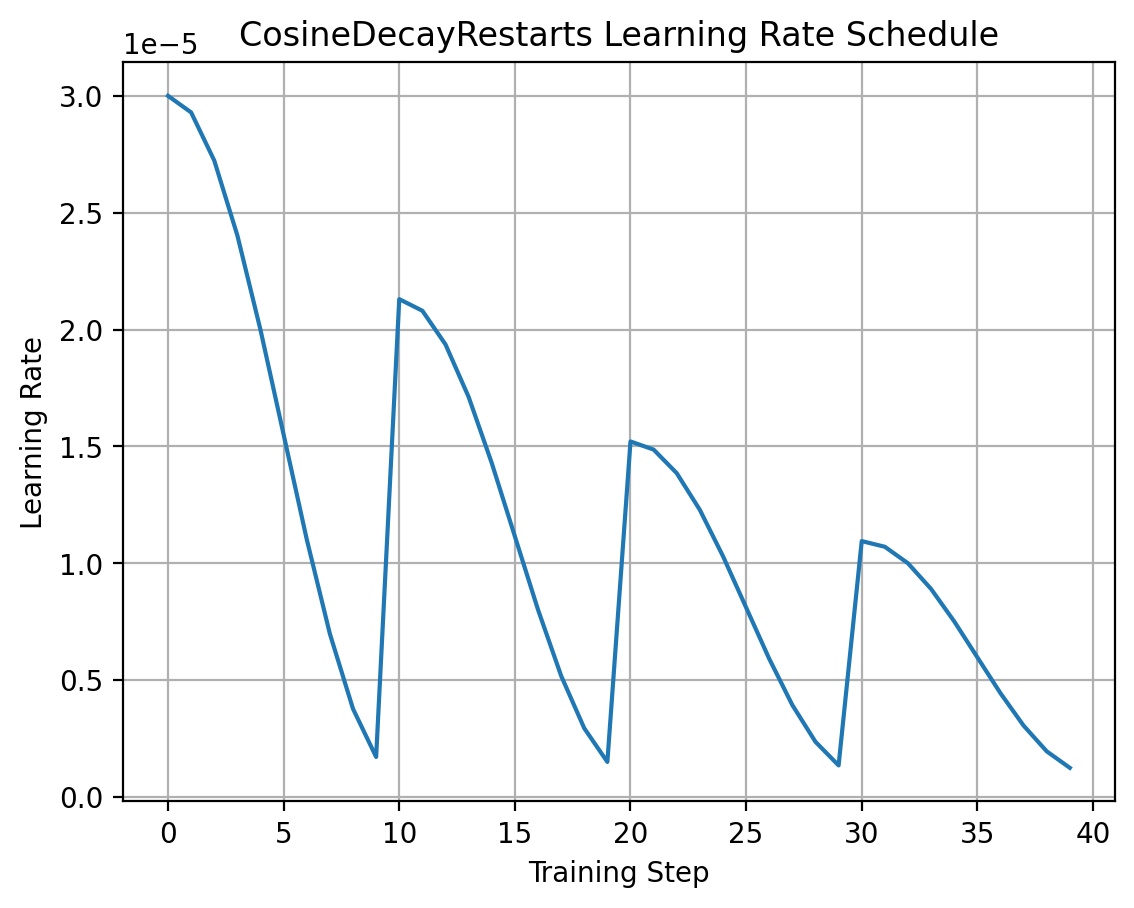

In [886]:
import matplotlib.pyplot as plt

initial_lr = 3e-5
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=10,     # Restart every 5 epochs
    t_mul=1.0,               # Increase the cycle length exponentially
    m_mul=0.7,               # Reduce the peak LR each restart
    alpha=1/30  # Final decay to minimum LR of 1e-6
)

steps = np.arange(40)
lrs = [lr_schedule(step).numpy() for step in steps]
plt.plot(steps, lrs)
plt.title("CosineDecayRestarts Learning Rate Schedule")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [266]:
### Only use if you want to save the model

model.save("gru attention model 2025-05-16 lag loss.keras")

TypeError: Huber.get_config() missing 1 required positional argument: 'self'

In [738]:
loss_fn = enhanced_lag_penalty_loss(beta=0.5, delta=0.05, alpha=1.0, 
                                            huber_weight=1.0)

directional_metric = DirectionalScoreMetric()

In [626]:
# from gru_attn_model.py import DirectionalScoreMetric, enhanced_lag_penalty_loss

# model = tf.keras.load_model(
#     "/Users/quinmcm/Documents/Python/Stock price/GRU Attention Model.keras",
#     custom_objects={
#         "DirectionalScoreMetric": DirectionalScoreMetric,
#         "enhanced_lag_penalty_loss": enhanced_lag_penalty_loss
#     }
# )

In [132]:
from tensorflow.keras.utils import register_keras_serializable
import tensorflow as tf

@register_keras_serializable()
class EnhancedPriceLoss(tf.keras.losses.Loss):
    def __init__(self, beta=0.05, alpha=5.0, delta=0.05, name="enhanced_price_loss"):
        super().__init__(name=name)
        self.beta = beta
        self.alpha = alpha
        self.delta = delta
        self.huber_loss = tf.keras.losses.Huber(delta=delta)

    def call(self, y_true_combined, y_pred):
        y_true_price = y_true_combined[:, 0:1]
        y_lagged_price = y_true_combined[:, 1:2]
        
        price_huber = self.huber_loss(y_true_price, y_pred)
        
        true_delta = y_true_price - y_lagged_price
        pred_delta = y_pred - y_lagged_price
        lag_penalty = tf.reduce_mean(tf.square(tf.abs(true_delta) - tf.abs(pred_delta)))
        
        vec_pred = y_pred - y_lagged_price
        vec_true = y_true_price - y_lagged_price
        dot_product = vec_pred * vec_true
        norm_pred = tf.linalg.norm(vec_pred, axis=0) + 1e-6
        norm_true = tf.linalg.norm(vec_true, axis=0) + 1e-6
        directional_score = tf.reduce_mean(dot_product / (norm_pred * norm_true))
        directional_loss = 1 - directional_score
        
        return price_huber + self.beta * lag_penalty + self.alpha * directional_loss

    def get_config(self):
        return {
            "beta": self.beta,
            "alpha": self.alpha,
            "delta": self.delta,
            "name": self.name
        }


In [45]:
model = tf.keras.models.load_model('GRU Attention Model 2.keras', custom_objects={"EnhancedPriceLoss": EnhancedPriceLoss})

I0000 00:00:1754170854.817743    9508 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1754170854.817823    9508 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [24]:
model = load_model('GRU Attention Model 4.keras', compile=False)  # or wherever your model is
model.compile(
    optimizer='adam',
    loss={
        'direction_output': 'categorical_crossentropy',
        'magnitude_output': 'mse',
        'price_output': 'mse'
    }
)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070, compute capability 8.6


In [ ]:
initial_lr = 2e-5
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=2783,
    decay_rate=0.90
)

# Generate steps and corresponding learning rates
steps = np.arange(0, 2783*25)  # Change upper bound to extend the range
lrs = [lr_schedule(step).numpy() for step in steps]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(steps, lrs, label='Learning Rate')
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Exponential Learning Rate Decay')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

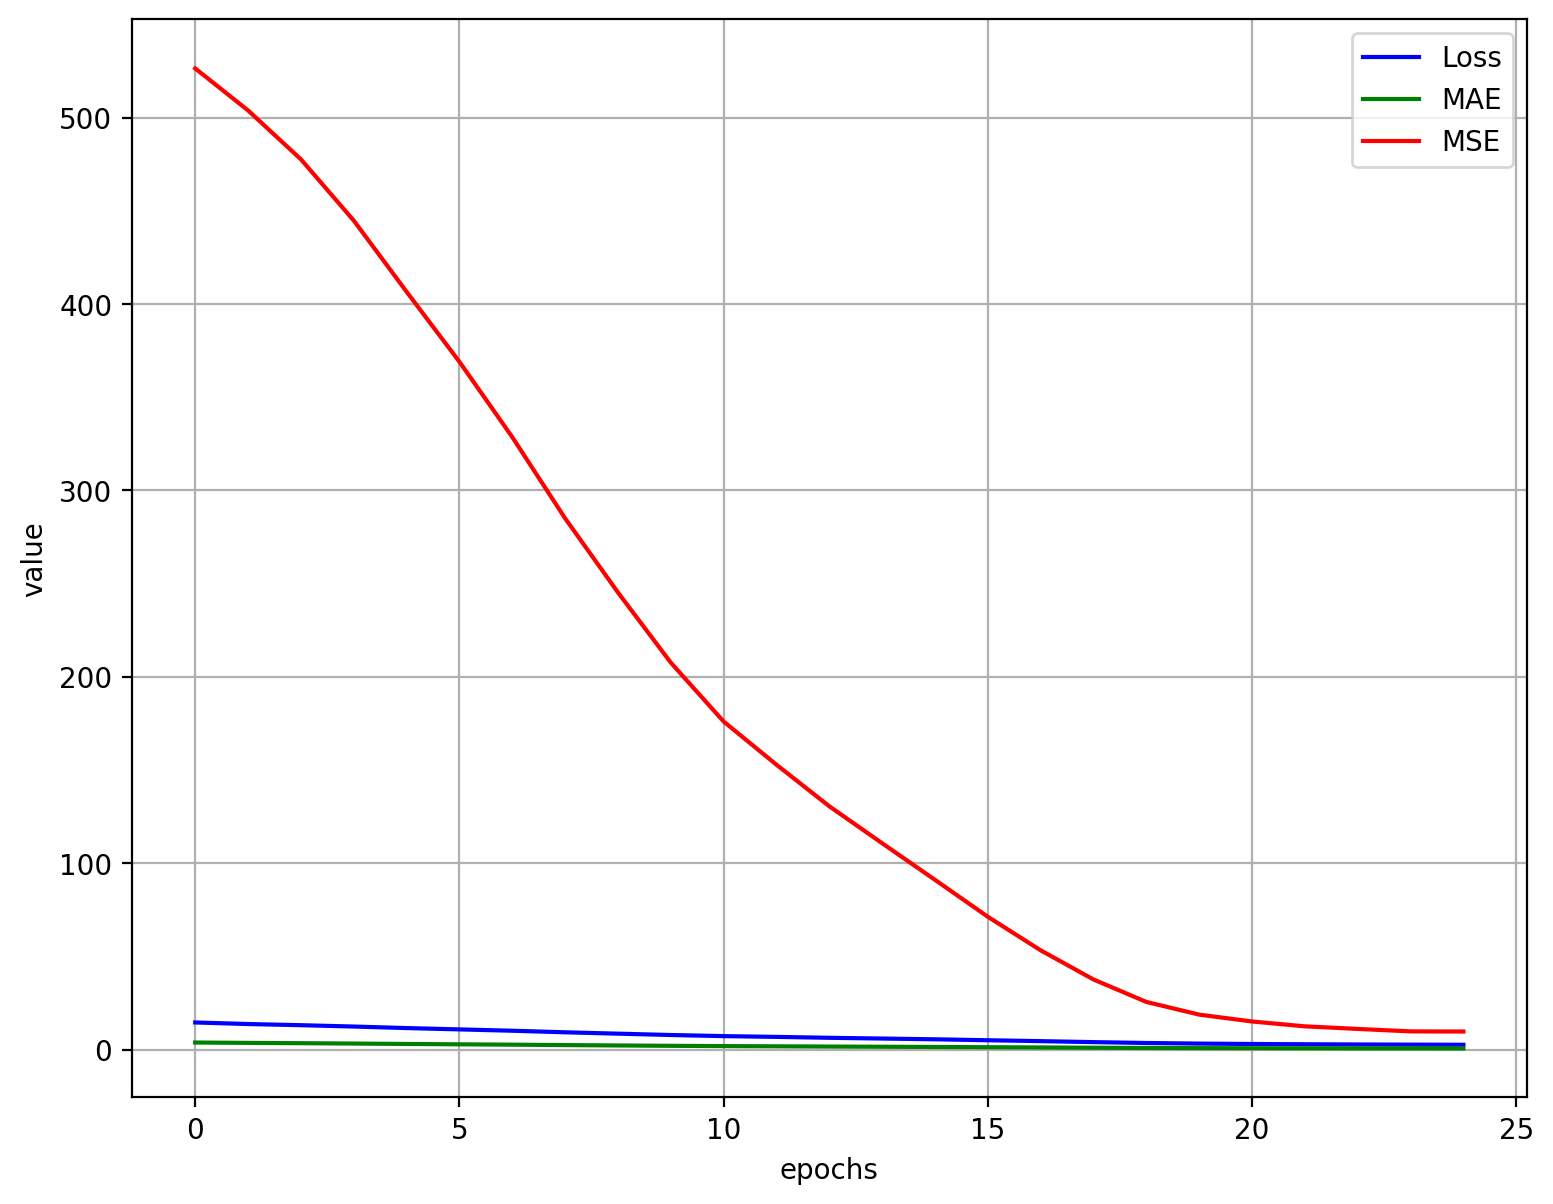

In [ ]:
plt.figure(figsize = (9,7))
plt.plot(history.history["loss"], c = 'b', label = 'Loss')
plt.plot(history.history['mae'], c = 'g', label = 'MAE')
plt.plot(history.history['mse'], c = 'r', label = 'MSE')

plt.xlabel('epochs')
plt.ylabel('value')
# plt.ylim(0,30)
# plt.xlim(-1,25)
plt.grid(True)
plt.legend()
plt.show()

In [50]:
ticker = 'NVDA'

new_data = yf.download(ticker, start = '2025-02-20', interval = '1h')

new_data.columns = new_data.columns.get_level_values(0)

C:\Users\quinl\AppData\Local\Temp\ipykernel_18868\944721489.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  new_data = yf.download(ticker, start = '2025-02-20', interval = '1h')
[*********************100%***********************]  1 of 1 completed


In [51]:
new_data.head(10)

Price,Close,High,Low,Open,Volume
Datetime,,,,,
2025-02-20 14:30:00+00:00,138.620605,140.529999,136.790100,140.130005,45160191
2025-02-20 15:30:00+00:00,138.300003,139.070007,137.110001,138.610001,20769192
2025-02-20 16:30:00+00:00,139.580002,139.970001,138.229996,138.300003,17027606
2025-02-20 17:30:00+00:00,139.490005,139.839600,139.089996,139.560303,11187948
2025-02-20 18:30:00+00:00,139.804901,140.000000,139.384995,139.490005,10655696
2025-02-20 19:30:00+00:00,139.899994,140.320007,139.380005,139.789993,14152452
2025-02-20 20:30:00+00:00,140.119995,140.199997,139.690002,139.889999,10091197
2025-02-21 14:30:00+00:00,139.229996,141.460007,138.949997,140.000000,48808452
2025-02-21 15:30:00+00:00,139.199203,139.720001,138.550003,139.229996,23381184


In [52]:
new_data = sma(new_data, 8)

new_data = ema(new_data, 8)

new_data = sma_diff(new_data, 8, 16)

new_data = ema_diff(new_data, 8, 16)

new_data = rsi(new_data, 20)

new_data = bbands(new_data,20)

new_data = MACD(new_data, fast = 12, slow = 26, signal = 9)

new_data = add_deltas(new_data)

new_data = rsi_vol(new_data, 20)
# new_data = volume_weighted_rsi(new_data, 40)

new_data = simple_momentum(new_data)

new_data = sma_roc(new_data, 20)

new_data = add_stochastic_oscillator(new_data)

new_data = add_ichimoku_cloud(new_data)

new_data = add_vwap(new_data)

new_data = add_lag_indicators(new_data)

new_data = fibonacci_retracements_rolling(new_data)

new_data = normalised_momentum(new_data, 20)

new_data = add_rvi(new_data)

new_data = add_volatility(new_data, 'Close', 10)

new_data = add_volatility(new_data, 'Close', 20)

new_data = add_volatility(new_data, 'Close', 60)

new_data = new_data.dropna()

new_data = new_data.drop(['High','Low','Open'], axis = 1)

In [ ]:
spx_df = yf.download('^SPX', start="2023-08-10")
spx_df.columns = data.columns.get_level_values(0)

vix_df = yf.download('^VIX', start="2023-08-10")
vix_df.columns = data.columns.get_level_values(0)

# new_data = add_market_features(new_data, spx_df, vix_df)

In [ ]:
spx_df.to_csv("Vanguard S&P 500 index.csv")

In [122]:
spx_df.head()

Price,Close,High,Low,Open,Volume
Ticker,^SPX,^SPX,^SPX,^SPX,^SPX
Date,,,,,
2023-08-10,4468.830078,4527.370117,4457.919922,4487.160156,4504370000
2023-08-11,4464.049805,4476.229980,4443.979980,4450.689941,3753290000
2023-08-14,4489.720215,4490.330078,4453.439941,4458.129883,3896410000
2023-08-15,4437.859863,4478.870117,4432.189941,4478.870117,3832250000
2023-08-16,4404.330078,4449.950195,4403.549805,4433.790039,3753910000


In [53]:
new_data.shape

(1671, 46)

In [54]:
threshold = 1e308

mask = (
    new_data.isna().any(axis=1) |
    np.isinf(new_data).any(axis=1) |
    (np.abs(new_data) > threshold).any(axis=1)
)

# Optionally print how many rows will be removed
print(f"Removing {mask.sum()} problematic rows.")

# Drop the problematic rows
new_data = new_data[~mask].copy()

Removing 3 problematic rows.


In [55]:
scalers = joblib.load("ticker_scalers.joblib")
feature_scaler = scalers[ticker]

In [56]:
feature_cols = []

for cols in new_data:
    feature_cols.append(cols)

scaled_df = feature_scaler.transform(new_data[feature_cols])

df_scaled = new_data.copy()
df_scaled[feature_cols] = scaled_df

scaled_df = df_scaled

In [57]:
df_scaled.head()

Price,Close,Volume,SMA_8,EMA_8,SMA_DIFF8,EMA_DIFF8,RSI,bb_mid_20,bb_high_20,bb_low_20,...,returns_20,volume_mean,volume_std,volume_z,momentum_pv,RVI,RVI_Signal,volatility_10,volatility_20,volatility_60
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-03-07 17:30:00+00:00,-0.449696,1.146553,-0.447500,-0.432940,-1.333496,-1.209379,-0.954138,-0.334094,-0.318078,-0.328496,...,-1.047863,0.835115,-0.049779,0.804972,-0.452871,-1.213472,-0.968861,0.025491,0.115039,1.176522
2025-03-07 18:30:00+00:00,-0.389855,0.604709,-0.444421,-0.422339,-1.160155,-0.984411,-0.697302,-0.345749,-0.347345,-0.324596,...,-0.960178,0.836029,-0.050364,-0.039993,0.758877,-1.163241,-1.105772,0.272217,0.200035,1.071500
2025-03-07 19:30:00+00:00,-0.377654,0.503049,-0.435487,-0.411366,-0.924279,-0.782373,-0.646837,-0.351637,-0.357802,-0.326421,...,-0.553529,0.829599,-0.045736,-0.188550,0.522033,-0.879111,-1.118679,-0.072708,-0.024798,1.065694
2025-03-07 20:30:00+00:00,-0.373357,0.340049,-0.428456,-0.401870,-0.693521,-0.618112,-0.628513,-0.357324,-0.369039,-0.327185,...,-0.538511,0.678912,-0.237931,-0.368136,0.629548,-0.528798,-0.983018,-0.075812,-0.022769,1.017454
2025-03-10 13:30:00+00:00,-0.533713,2.507762,-0.439288,-0.430346,-0.555756,-0.833115,-1.068142,-0.370216,-0.370675,-0.349813,...,-1.077971,0.787799,-0.059570,2.997791,-3.913466,-0.261045,-0.737485,0.998645,0.631964,1.201546


In [58]:
X_test, y_test = create_sequences(
    scaled_df,
    feature_cols,
    'Close',
    100,
    8
)

X_test = X_test[1:]

In [59]:
y_test.shape

(1561,)

In [60]:
X_test.shape

(1560, 100, 46)

In [61]:
def prepare_multitask_targets_from_y(y_train_scaled, threshold=0.001):
    """
    Prepare multitask targets aligned with X_train using y_train (already aligned/scaled).

    Args:
        y_train_scaled (np.ndarray): The array of next-day prices for each input sequence.
        threshold (float): Minimum delta to label direction.

    Returns:
        dict: Aligned targets for multi-task output.
    """
    # Skip the first sample since we can't calculate a proper price change for it
    y_prices = y_train_scaled[1:].reshape(-1, 1)  # Current prices (excluding first)
    y_lagged = y_train_scaled[:-1].reshape(-1, 1)  # Previous prices (excluding last)

    # 1. Price target for custom loss
    price_combined = np.concatenate([y_prices, y_lagged], axis=1)

    # 2. Price change
    price_changes = y_prices - y_lagged

    # 3. Direction targets (Up=0, Down=1, Flat=2)
    direction_classes = np.where(
        price_changes > threshold, 0,
        np.where(price_changes < -threshold, 1, 2)
    ).astype(np.int32).flatten()

    direction_onehot = tf.keras.utils.to_categorical(direction_classes, num_classes=3)

    # 4. Magnitude targets
    magnitude = np.abs(price_changes)

    # ✅ Sanity print
    print("Shapes:")
    print(f"  y_prices: {y_prices.shape}")
    print(f"  price_combined: {price_combined.shape}")
    print(f"  direction_classes: {direction_classes.shape}")
    print(f"  direction_onehot: {direction_onehot.shape}")
    print(f"  magnitude: {magnitude.shape}")

    return {
        'price_combined': price_combined,
        'direction_onehot': direction_onehot,
        'direction_classes': direction_classes,
        'magnitude': magnitude,
        'price_changes': price_changes
    }


In [62]:
targets_dict = prepare_multitask_targets_from_y(y_test, threshold=0.001)

y_test_dict = {
        'price_output': targets_dict['price_combined'],
        'direction_output': targets_dict['direction_onehot'],
        'magnitude_output': targets_dict['magnitude']
    }

Shapes:
  y_prices: (1560, 1)
  price_combined: (1560, 2)
  direction_classes: (1560,)
  direction_onehot: (1560, 3)
  magnitude: (1560, 1)


In [63]:
results = model.evaluate(X_test, y_test_dict, return_dict=True)
for k, v in results.items():
    print(f"{k}: {v:.4f}")


49/49 [==============================] - 1s 11ms/step - loss: 0.9664 - direction_output_loss: 0.8043 - magnitude_output_loss: 0.0019 - price_output_loss: 0.1602
loss: 0.9664
direction_output_loss: 0.8043
magnitude_output_loss: 0.0019
price_output_loss: 0.1602


In [64]:
# Make a prediction on the test set
y_pred_on_test = model.predict(X_test)
y_pred_on_test = y_pred_on_test['price_output']

49/49 [==============================] - 1s 13ms/step


In [65]:
y_test = y_test[:len(y_pred_on_test)]

In [66]:
close_idx = feature_cols.index("Close")  # must be the same order as training
n_features = len(feature_cols)

dummy = np.zeros((len(y_pred_on_test), n_features))
dummy[:, close_idx] = y_pred_on_test.flatten()

dummy_inv = feature_scaler.inverse_transform(dummy)

predicted_prices = dummy_inv[:, close_idx]


close_idx = feature_cols.index("Close")  # must be the same order as training
n_features = len(feature_cols)

dummy = np.zeros((len(y_test), n_features))
dummy[:, close_idx] = y_test.flatten()

dummy_inv_test = feature_scaler.inverse_transform(dummy)

test_prices = dummy_inv_test[:, close_idx]

In [67]:
def inverse_transform_target(feature_scaler, target_col, y_values, df_columns=None, df_sample_shape=None):
    """
    feature_scaler: your FeatureScaler object (may have .scalers dict or .inverse_transform)
    target_col: name of target column, e.g. 'Close'
    y_values: 1D or 2D array of predicted/actual target values (in scaled space)
    df_columns: list-like of original df.columns (optional, used if scaler is multi-column)
    df_sample_shape: tuple (n_features,) used only if scaler is a multi-col scaler that needs full-width input
    """
    import numpy as np

    y_arr = np.asarray(y_values)
    # make 2D column vector
    if y_arr.ndim == 1:
        y_arr = y_arr.reshape(-1, 1)

    # Case A: per-column scalers stored e.g. feature_scaler.scalers['Close']
    if hasattr(feature_scaler, 'scalers') and target_col in feature_scaler.scalers:
        scaler = feature_scaler.scalers[target_col]
        return scaler.inverse_transform(y_arr).ravel()

    # Case B: scaler was fitted to whole dataframe (e.g. a single MinMax/StandardScaler)
    # We'll create a dummy full-width array, fill the target column, inverse_transform, then extract that column.
    if hasattr(feature_scaler, 'inverse_transform'):
        if df_columns is None and df_sample_shape is None:
            raise ValueError("Need df_columns or df_sample_shape to inverse transform a multi-column scaler.")
        # determine full width
        if df_columns is not None:
            n_features = len(df_columns)
            try:
                target_idx = list(df_columns).index(target_col)
            except ValueError:
                raise ValueError("target_col not in df_columns")
        else:
            n_features = df_sample_shape[0]
            target_idx = 0  # if you passed shape where target is first—adjust as needed

        # construct dummy array
        full = np.zeros((y_arr.shape[0], n_features))
        full[:, target_idx:target_idx+1] = y_arr
        inv_full = feature_scaler.inverse_transform(full)
        return inv_full[:, target_idx].ravel()

    raise RuntimeError("Cannot find a method to inverse transform. Check your FeatureScaler implementation.")

In [ ]:
sequence_length=60
prediction_offset=8

y_pred = np.asarray(y_pred_on_test)
y_true = np.asarray(y_test)

# use helper (adjust call if your FeatureScaler stores different attributes)
predicted_prices = inverse_transform_target(feature_scaler, 'Close', y_pred, df_columns=combined_df.columns)
actual_prices    = inverse_transform_target(feature_scaler, 'Close', y_true,    df_columns=combined_df.columns)

# Build the correct index mapping
start_index = sequence_length + prediction_offset - 1
pred_indices = np.arange(start_index, start_index + len(predicted_prices))
# make sure df has a DatetimeIndex (if not, use df.index)
result_index = combined_df.index.values[pred_indices]

results = pd.DataFrame({
    'predicted': predicted_prices,
    'actual':    actual_prices
}, index=pd.Index(result_index, name=getattr(combined_df.index, 'name', None)))

# optional: show a few rows
print(results.head())

NameError: name 'combined_df' is not defined

In [68]:
print(len(predicted_prices))
print(len(result_index))
print(len(actual_prices))

1560


NameError: name 'result_index' is not defined

In [69]:
print(X_test.shape)
print(y_test.shape)
print(y_pred_on_test.shape)

(1560, 100, 46)
(1560,)
(1560, 1)


In [70]:
actual_prices = y_test
predicted_prices = y_pred_on_test

In [115]:
predicted_prices = predicted_prices + 2.1

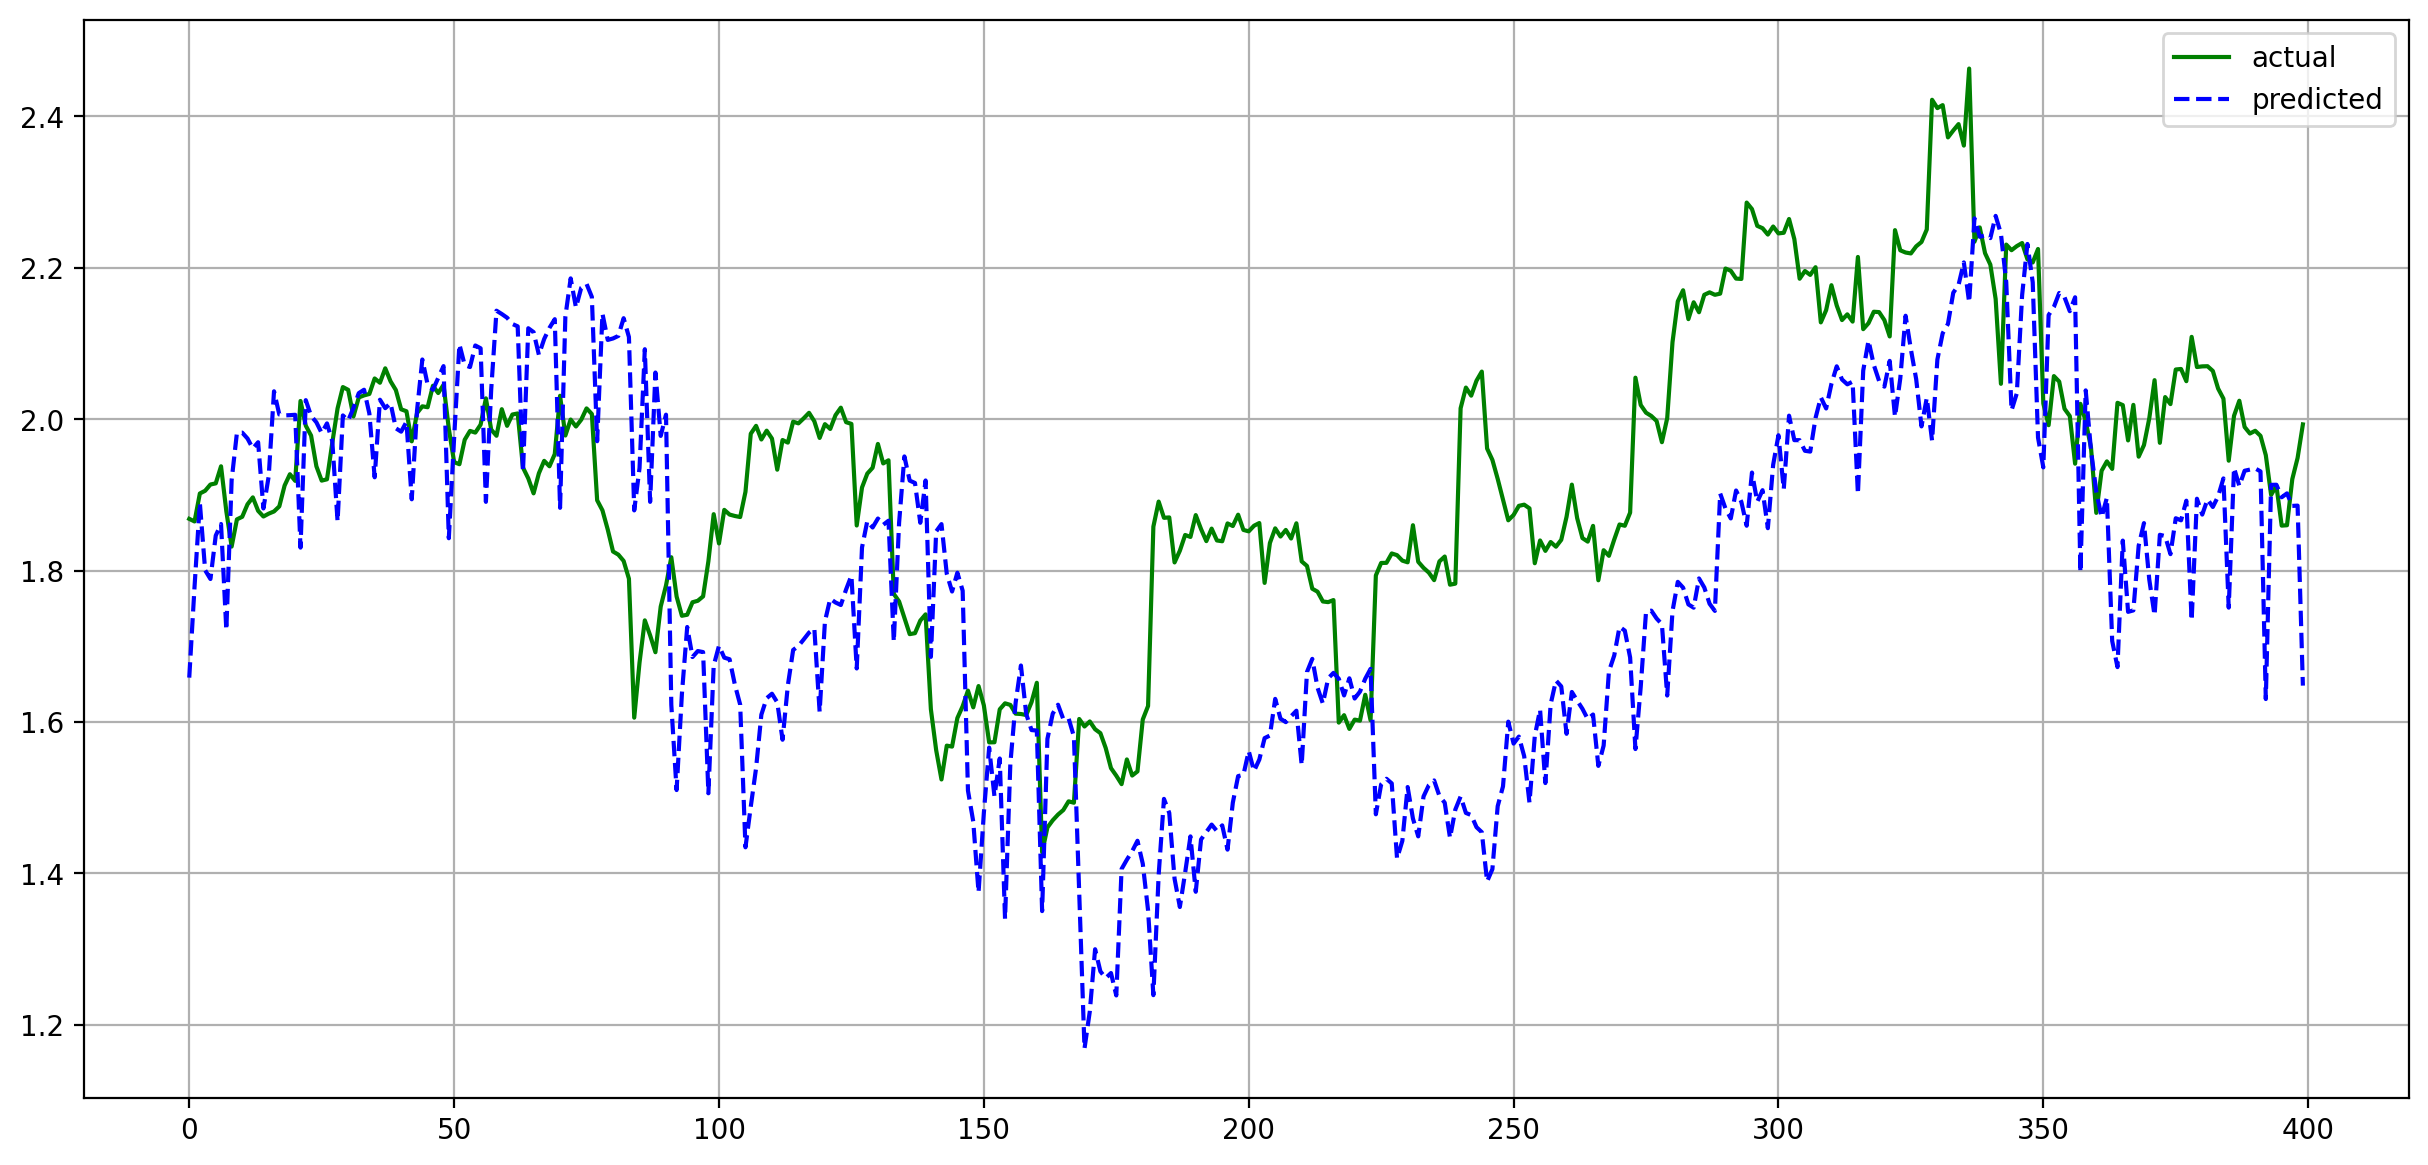

In [72]:
plt.figure(figsize = (15,7))
plt.plot(actual_prices[600:1000], label = "actual", c = "g")
plt.plot(predicted_prices[600:1000], 'b--', label = "predicted")
plt.legend()
plt.grid()
plt.show()

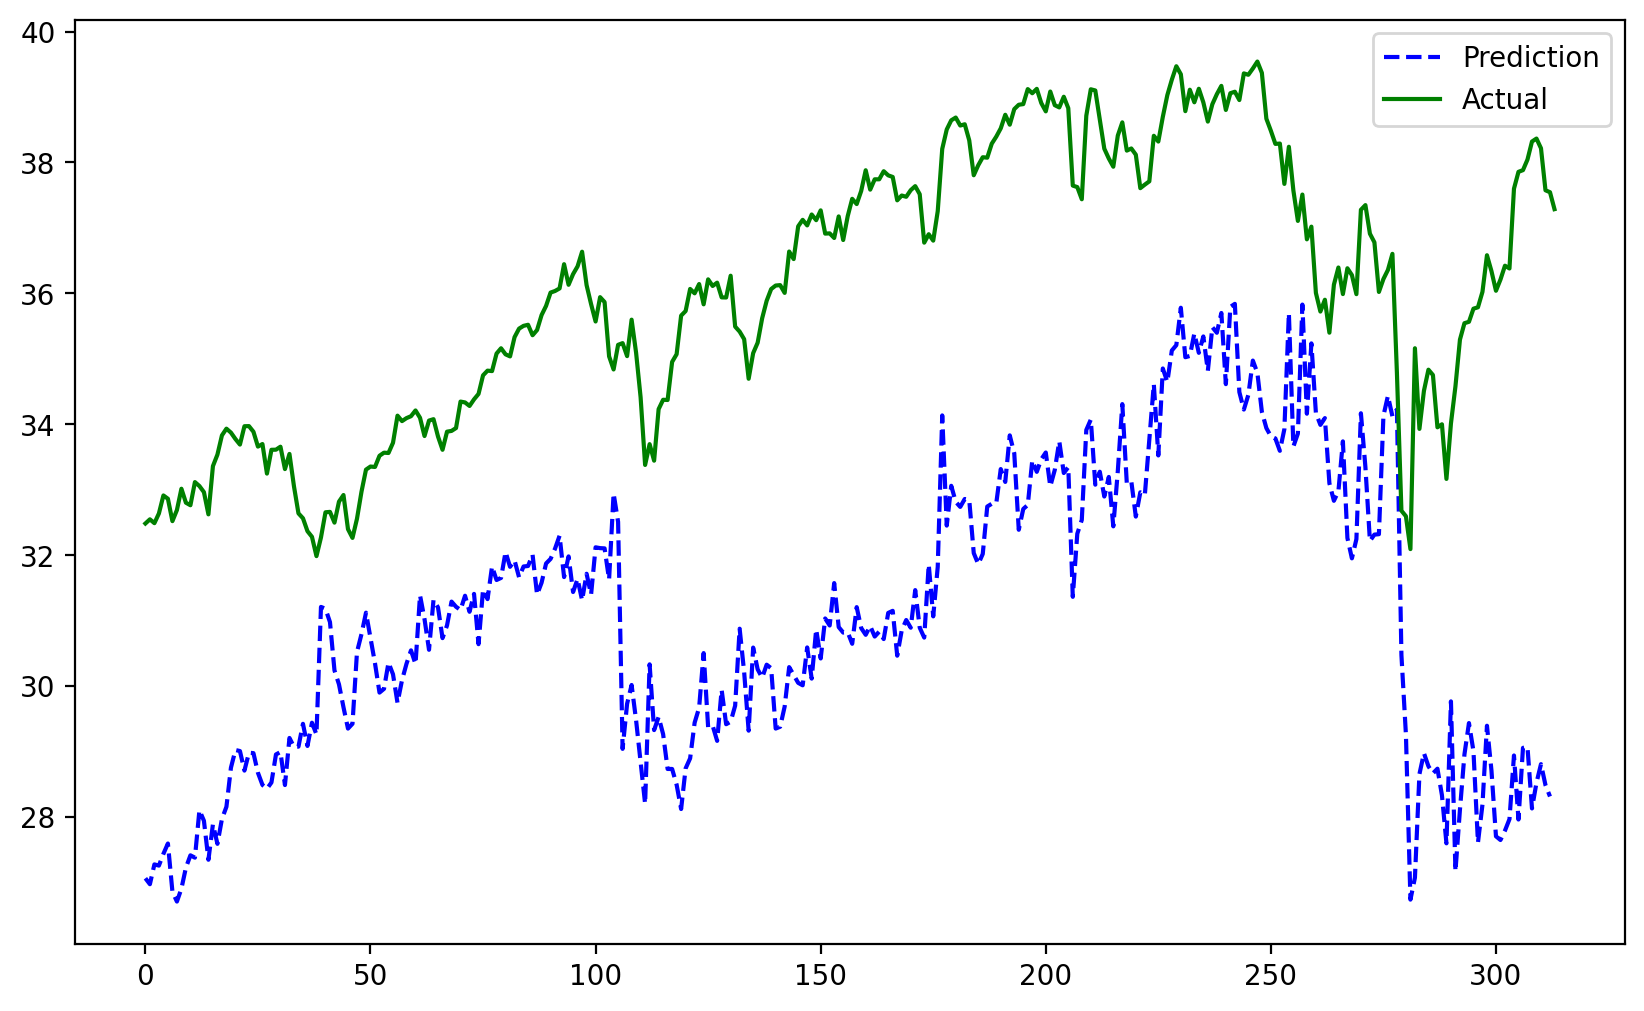

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(y_pred_on_test-0.025, 'b--', label = "Prediction")
plt.plot(y_test, label = "Actual", c = "g")
plt.legend()
plt.show()

In [95]:
y_pred = model.predict(X_train)

2519/2519 [==============================] - 27s 11ms/step


In [115]:
# residuals = (y_train - y_pred['price_output']).reshape(-1)
# abs_residuals = np.abs(residuals)

residuals = []

for i in range(len(y_train)//1000, 1000):
    res = (y_train[i:i+1000] - y_pred['price_output'][i:i+1000])
    residuals.append(res)

residuals = np.concatenate(residuals)

abs_residuals = np.abs(residuals)

In [119]:
median = np.median(abs_residuals)
mad = np.median(np.abs(abs_residuals - median))

delta = 1.345 * mad

print(delta)

0.3259639056235923


In [ ]:
# Ensure shape is (n_samples, 1)
actual_prices = actual_prices.reshape(-1, 1)
predicted_prices = predicted_prices.reshape(-1, 1)

# Roll values backward to create lag
y_lagged = np.roll(actual_prices, shift=1, axis=0)

# Handle the first value (since it gets rolled from the end)
y_lagged[0] = predicted_prices[0]  # or you could set to 0 if preferred

def directional_breakdown(y_true, y_pred, y_lagged):
    """
    Returns counts of directional prediction outcomes:
    - Correct Up
    - Incorrect Up
    - Correct Down
    - Incorrect Down
    - No Change
    """
    # Ensure inputs are numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_lagged = np.asarray(y_lagged)
    
    # Check if shapes match
    if not (y_true.shape == y_pred.shape == y_lagged.shape):
        raise ValueError(f"Input arrays must have the same shape. Got shapes: y_true: {y_true.shape}, y_pred: {y_pred.shape}, y_lagged: {y_lagged.shape}")

    # Compute actual and predicted deltas
    true_diff = y_true - y_lagged
    pred_diff = y_pred - y_lagged

    # Determine direction
    true_up = true_diff > 0
    true_down = true_diff < 0
    true_same = true_diff == 0
    pred_up = pred_diff > 0
    pred_down = pred_diff < 0
    pred_same = pred_diff == 0

    # Count each case
    correct_up = np.sum((true_up) & (pred_up))
    incorrect_up = np.sum((true_down) & (pred_up))
    missed_up = np.sum((true_up) & (pred_down))
    
    correct_down = np.sum((true_down) & (pred_down))
    incorrect_down = np.sum((true_up) & (pred_down))
    missed_down = np.sum((true_down) & (pred_up))
    
    # No change cases
    true_no_change = np.sum(true_same)
    pred_no_change = np.sum(pred_same)
    correct_no_change = np.sum(true_same & pred_same)
    
    # Check if total counts match array size
    total_classified = correct_up + incorrect_up + correct_down + incorrect_down + \
                       np.sum(true_same | pred_same) - np.sum(true_same & pred_same)
    
    if total_classified != len(y_true):
        print(f"Warning: Total classified cases ({total_classified}) doesn't match input length ({len(y_true)})")
    
    # Create results dictionary
    results = {
        "Correct Up Predictions": int(correct_up),
        "Incorrect Up Predictions": int(incorrect_up),
        "Correct Down Predictions": int(correct_down),
        "Incorrect Down Predictions": int(incorrect_down),
        "True No Change": int(true_no_change),
        "Predicted No Change": int(pred_no_change),
        "Correct No Change": int(correct_no_change),
        "Total Observations": len(y_true)
    }
    
    # Print summary percentages
    total = len(y_true)
    print("\nSummary Percentages:")
    for key, value in results.items():
        print(f"{key}: {value} ({value/total*100:.2f}%)")
        
    return results


# When calling the function:
result = directional_breakdown(actual_prices, predicted_prices, y_lagged)

ValueError: Input arrays must have the same shape. Got shapes: y_true: (309, 1), y_pred: (308, 1), y_lagged: (309, 1)

## Actual prediction making

In [ ]:
def get_new_values(ticker, start_date):
    """
    For the current use case, use the ticker ^GSPC
    """
    
    todays_date = datetime.today().strftime('%Y-%m-%d')
    
    new_dataframe = yf.download(ticker, start = start_date, end = todays_date)
    
    return new_dataframe


def add_values(new_dataframe, dataframe):
    
    new_dataframe = new_dataframe[['Close', 'Open']]
    new_dataframe = new_dataframe.rename(columns = {'Close' : 'close', 'Open': 'open'})
    
    concatenated_dataframe = pd.concat([dataframe, new_dataframe], axis = 0, join = 'outer')
    
    return concatenated_dataframe


def reshape_arrays(df, time_step):
    X = df.iloc[- time_step - 1:-1]

    X = X.to_numpy()

    X = feature_scaler.transform(X)

    X = X.reshape(1,time_step,10)

    return X

In [ ]:
new_data = yf.download('MSFT', '2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [ ]:
fresh_data_1 = {'Close': 5641.00}

In [ ]:
fresh_data_2 = {'Close': 4270.25}

In [ ]:
fresh_data_1 = pd.DataFrame(fresh_data_1, index=['2024-08-21'])

In [ ]:
fresh_data_2 = pd.DataFrame(fresh_data_2, index=['2023-10-24'])

In [ ]:
new_data = new_data.append(fresh_data_1)

/var/folders/yg/069hjm3s3h93pz6xvwym8qxr0000gn/T/ipykernel_746/4058603128.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_data = new_data.append(fresh_data_1)


In [ ]:
new_data = new_data.append(fresh_data_2)

/var/folders/yg/069hjm3s3h93pz6xvwym8qxr0000gn/T/ipykernel_4548/531779635.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_data = new_data.append(fresh_data_2)


In [ ]:
new_data.columns = new_data.columns.get_level_values(0)

In [ ]:
new_data = sma(new_data, 20)

new_data = ema(new_data, 20)

new_data = sma_diff(new_data, 10, 20)

new_data = ema_diff(new_data, 10, 20)

new_data = rsi(new_data, 20)

new_data = bbands(new_data,20)

new_data = MACD(new_data, fast = 12, slow = 26, signal = 9)

new_data = add_deltas(new_data)

new_data = rsi_vol(new_data, 20)
# new_data = volume_weighted_rsi(new_data, 40)

new_data = simple_momentum(new_data)

new_data = sma_roc(new_data, 20)

new_data = add_stochastic_oscillator(new_data)

new_data = add_ichimoku_cloud(new_data)

new_data = add_vwap(new_data)

new_data = add_lag_indicators(new_data)

new_data = fibonacci_retracements_rolling(new_data)

new_data = normalised_momentum(new_data, 20)

new_data = add_rvi(new_data)

new_data = add_volatility(new_data, 'Close', 10)

new_data = add_volatility(new_data, 'Close', 20)

new_data = add_volatility(new_data, 'Close', 60)

new_data = new_data.dropna()

new_data = new_data.drop(['High','Low','Open'], axis = 1)

In [ ]:
def get_data(ticker, start_date = '2023-01-01'):
    new_data = yf.download(ticker, start_date)
    new_data.columns = new_data.columns.get_level_values(0)

    return new_data

In [ ]:
def add_indicators(new_data):
    new_data = sma(new_data, 20)
    new_data = ema(new_data, 20)
    new_data = sma_diff(new_data, 10, 20)
    new_data = ema_diff(new_data, 10, 20)
    new_data = rsi(new_data, 20)
    new_data = bbands(new_data,20)
    new_data = MACD(new_data, fast = 12, slow = 26, signal = 9)
    new_data = add_deltas(new_data)
    new_data = rsi_vol(new_data, 20)
    new_data = simple_momentum(new_data)
    new_data = sma_roc(new_data, 20)
    new_data = add_stochastic_oscillator(new_data)
    new_data = add_ichimoku_cloud(new_data)
    new_data = add_vwap(new_data)
    new_data = add_lag_indicators(new_data)
    new_data = fibonacci_retracements_rolling(new_data)
    new_data = normalised_momentum(new_data, 20)
    new_data = add_rvi(new_data)
    new_data = add_volatility(new_data, 'Close', 10)
    new_data = add_volatility(new_data, 'Close', 20)
    new_data = add_volatility(new_data, 'Close', 60)
    new_data = new_data.dropna()
    new_data = new_data.drop(['High','Low','Open'], axis = 1)

    return new_data

In [ ]:
def remove_inf(df, threshold = 1e308):
    mask = (
        df.isna().any(axis=1) |
        np.isinf(df).any(axis=1) |
        (np.abs(df) > threshold).any(axis=1)
    )
    print(f"Removing {mask.sum()} problematic rows.")

    df = df[~mask].copy()

    return df

In [ ]:
spx_df = yf.download('^SPX', start="2023-01-01")
spx_df.columns = data.columns.get_level_values(0)

vix_df = yf.download('^VIX', start="2023-01-01")
vix_df.columns = data.columns.get_level_values(0)

new_data = add_market_features(new_data, spx_df, vix_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
threshold = 1e308

mask = (
    new_data.isna().any(axis=1) |
    np.isinf(new_data).any(axis=1) |
    (np.abs(new_data) > threshold).any(axis=1)
)

# Optionally print how many rows will be removed
print(f"Removing {mask.sum()} problematic rows.")

# Drop the problematic rows
new_data = new_data[~mask].copy()

Removing 0 problematic rows.


In [ ]:
def unscale(y_pred_on_test, y_test):
    if y_pred_on_test.ndim == 1:
        y_pred_on_test = y_pred_on_test.reshape(-1, 1)

    # Now use the scaler for just the target column
    predicted_prices = feature_scaler.scalers['Close'].inverse_transform(y_pred_on_test)

    # If you want it back as flat 1D array
    predicted_prices = predicted_prices.flatten()


    if y_test.ndim == 1:
        y_test = y_test.reshape(-1, 1)

    # Now use the scaler for just the target column
    actual_prices = feature_scaler.scalers['Close'].inverse_transform(y_test)

    # If you want it back as flat 1D array
    actual_prices = actual_prices.flatten()

    return predicted_prices, actual_prices

In [ ]:
def prediction(predicted_prices, ticker):
    pct_change = ((predicted_prices[-1] - predicted_prices[-2]) / predicted_prices[-2]) * 100
    if predicted_prices[-1] < predicted_prices[-2]:
        return(f'{ticker} predicted down by {pct_change:.2f}%')
    if predicted_prices[-1] > predicted_prices[-2]:
        return(f'{ticker} predicted up by   {pct_change:.2f}%')
    if predicted_prices[-1] == predicted_prices[-2]:
        return("Huh???")

In [ ]:
def prediction_call():

    # tickers = ['AAPL']

    tickers = ['NVDA', 'META', 'AAPL', 'AMZN', 'MSFT', 'NFLX', 'TSLA']

    spx_df = yf.download('^SPX', start="2023-01-01")
    spx_df.columns = data.columns.get_level_values(0)

    vix_df = yf.download('^VIX', start="2023-01-01")
    vix_df.columns = data.columns.get_level_values(0)

    results = []

    for ticker in tickers:

        new_data = get_data(ticker)
        new_data = add_market_features(new_data, spx_df, vix_df)
        new_data = add_indicators(new_data)
        new_data = remove_inf(new_data)

        X_test, y_test, _, _, = create_sequences(new_data, 60, feature_scaler = feature_scaler)

        y_pred_on_test = model.predict(X_test)
        y_pred_on_test = y_pred_on_test['price_output']

        predicted, actual = unscale(y_pred_on_test, y_test)

        results.append(prediction(predicted, ticker))

    for r in results:
        print(r)

In [ ]:
prediction_call()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Removing 0 problematic rows.
 4/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


[*********************100%***********************]  1 of 1 completed

Removing 0 problematic rows.
 4/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

...

Removing 0 problematic rows.
 3/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


[*********************100%***********************]  1 of 1 completed

Removing 0 problematic rows.
 4/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
NVDA predicted up by   1.11%
META predicted down by -1.86%
AAPL predicted down by -0.12%
AMZN predicted up by   1.14%
MSFT predicted up by   0.74%
NFLX predicted down by -9.16%
TSLA predicted down by -5.82%


In [ ]:
X_test, y_test, _, _ = create_sequences(new_data, 60, feature_scaler = feature_scaler)

In [ ]:
# scaled_test = feature_scaler.transform(new_data)

# sequence_length = 100
# target_idx = new_data.columns.get_loc('Close')

# X_test, y_test = [], []
# for i in range(sequence_length, len(scaled_test)):
#     X_test.append(scaled_test[i-sequence_length: i])
#     y_test.append(scaled_test[i, target_idx])

# X_test, y_test = np.array(X_test), np.array(y_test)

In [ ]:
new_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2025-09-09,498.410004,502.250000,497.700012,501.429993,14410500
2025-09-10,500.369995,503.230011,496.720001,502.980011,21611800
2025-09-11,501.010010,503.170013,497.880005,502.250000,18881600
2025-09-12,509.899994,512.549988,503.850006,506.649994,23612600
2025-09-15,515.359985,515.469971,507.000000,508.750000,16987592


In [ ]:
X_test.shape

(530, 60, 48)

In [ ]:
y_pred_on_test = model.predict(X_test)
y_pred_on_test = y_pred_on_test['price_output']

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
if y_pred_on_test.ndim == 1:
    y_pred_on_test = y_pred_on_test.reshape(-1, 1)

# Now use the scaler for just the target column
predicted_prices = feature_scaler.scalers['Close'].inverse_transform(y_pred_on_test)

# If you want it back as flat 1D array
predicted_prices = predicted_prices.flatten()


if y_test.ndim == 1:
    y_test = y_test.reshape(-1, 1)

# Now use the scaler for just the target column
actual_prices = feature_scaler.scalers['Close'].inverse_transform(y_test)

# If you want it back as flat 1D array
actual_prices = actual_prices.flatten()

In [ ]:
def unscale(y_pred_on_test, y_test):
    if y_pred_on_test.ndim == 1:
        y_pred_on_test = y_pred_on_test.reshape(-1, 1)

    # Now use the scaler for just the target column
    predicted_prices = feature_scaler.scalers['Close'].inverse_transform(y_pred_on_test)

    # If you want it back as flat 1D array
    predicted_prices = predicted_prices.flatten()


    if y_test.ndim == 1:
        y_test = y_test.reshape(-1, 1)

    # Now use the scaler for just the target column
    actual_prices = feature_scaler.scalers['Close'].inverse_transform(y_test)

    # If you want it back as flat 1D array
    actual_prices = actual_prices.flatten()

    return predicted_prices, actual_prices

In [ ]:
actual_prices[-5:]

array([504.26000977, 502.04000854, 506.73999023, 509.64001465,
       506.69000244])

In [ ]:
predicted_prices[-6:]

array([474.56482, 479.7484 , 473.11206, 475.37772, 477.10123, 473.9103 ],
      dtype=float32)

In [ ]:
def prediction(predicted_prices):
    if predicted_prices[-1] < predicted_prices[-2]:
        print("Predicted down")
    if predicted_prices[-1] > predicted_prices[-2]:
        print("Predicted up")
    if predicted_prices[-1] == predicted_prices[-2]:
        print("Huh???")

prediction()

Predicted down


In [ ]:
((predicted_prices[-1] - predicted_prices[-2]) / predicted_prices[-2]) * 100

np.float32(0.34184185)

In [ ]:
ESMini_prediction = np.append(ESMini_prediction, predicted_prices)

In [ ]:
ESMini_prediction[-5:]

array([[0.13974312],
       [0.1366348 ],
       [0.13765135],
       [0.14166209],
       [0.14484838]], dtype=float32)

In [ ]:
final_el_list = new_data['close'].iloc[-365:]

std_dev = np.std(final_el_list)

print(std_dev)

466.34734552899715


# Prediction Clean Up

In [ ]:
new_data_ESMini = new_data

# ESMini_array = new_data_ESMini.to_numpy()

ESMini_scaled = feature_scaler.transform(new_data_ESMini)

In [ ]:
ESMini_test = []

sequence_length = 60

for i in range(sequence_length, new_data.shape[0]):
    ESMini_test.append(ESMini_scaled[i - sequence_length : i, :])

ESMini_array = np.array(ESMini_test)

InvalidIndexError: (slice(0, 60, None), slice(None, None, None))

In [ ]:
ESMini_prediction = model.predict(ESMini_array)

actual_prices, predicted_prices = inverse_transform_predictions(ESMini_prediction, y_test, feature_scaler, new_data)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
print(type(ESMini_prediction))

<class 'numpy.ndarray'>


In [ ]:
ESMini_prediction_list = np.reshape(predicted_prices, (-1))

In [ ]:
# calc difference between new_data shape and prediction list
diff = new_data.shape[0] - ESMini_prediction_list.shape[0]

# create list of 0's of length diff
set_vals = [0 for _ in range(diff)]

# set prediction list to type list
ESMini_prediction_list = ESMini_prediction_list.tolist()

In [ ]:
ESMini_prediction_list = set_vals + ESMini_prediction_list

In [ ]:
prediction_dates = new_data.index

prediction_df = pd.DataFrame({
    'prediction': ESMini_prediction_list
}, index = prediction_dates)

In [ ]:
result_df = new_data.merge(prediction_df, left_index = True, right_index = True, how = 'left')

In [ ]:
result_df['target'] = result_df['Close'].shift(-1)

In [ ]:
result_df.tail(20)

,Close,High,Low,Volume,SMA_20,EMA_20,RSI,bb_mid_15,bb_high_15,bb_low_15,...,Volume_lag3,Volume_lag5,Volume_lag10,RSI_lag1,RSI_lag2,RSI_lag3,RSI_lag5,RSI_lag10,prediction,target
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-17,5680.250000,5707.50,5599.00,2086734,5846.51250,5793.197395,39.814057,5763.616667,6063.490382,5463.742951,...,2004740.0,2590102.0,2610882.0,36.929204,27.915724,30.730306,29.843176,37.073906,5643.261333,5618.000000
2025-03-18,5618.000000,5686.25,5600.00,1111733,5820.07500,5776.511929,37.009014,5740.150000,6025.549332,5454.750668,...,2163776.0,2623963.0,3353551.0,39.814057,36.929204,27.915724,28.306800,33.354719,5739.650268,5678.500000
2025-03-19,5678.500000,5718.50,5606.25,704394,5795.85000,5767.177459,41.314416,5720.666667,5977.023050,5464.310283,...,2191954.0,2004740.0,2284032.0,37.009014,39.814057,36.929204,30.730306,39.033873,5664.686840,5662.500000
2025-03-20,5662.500000,5714.25,5631.50,412785,5772.15000,5757.208178,40.529480,5706.416667,5949.107730,5463.725603,...,2086734.0,2163776.0,2553819.0,41.314416,37.009014,39.814057,27.915724,33.788266,5685.808934,5617.799805
2025-03-21,5617.799805,5674.25,5597.50,1629871,5751.58999,5743.931190,38.348586,5683.386654,5883.443930,5483.329378,...,1111733.0,2191954.0,2315005.0,40.529480,41.314416,37.009014,36.929204,36.383547,5728.367771,5815.500000
2025-03-24,5815.500000,5825.50,5739.00,1404629,5742.32749,5750.747267,50.875006,5680.369987,5870.061371,5490.678603,...,704394.0,2086734.0,2590102.0,38.348586,40.529480,41.314416,39.814057,29.843176,5663.963142,5826.500000
2025-03-25,5826.500000,5837.25,5802.25,1078548,5735.15249,5757.961813,51.462911,5682.836654,5879.445931,5486.227376,...,412785.0,1111733.0,2623963.0,50.875006,38.348586,40.529480,37.009014,28.306800,5829.033717,5759.500000
2025-03-26,5759.500000,5836.50,5743.00,1483959,5724.58999,5758.108307,47.734835,5676.719987,5855.801961,5497.638013,...,1629871.0,704394.0,2004740.0,51.462911,50.875006,38.348586,41.314416,30.730306,5867.627948,5739.250000
2025-03-27,5739.250000,5779.75,5720.00,1575855,5717.73999,5756.312278,46.640705,5676.253320,5854.593725,5497.912915,...,1404629.0,412785.0,2163776.0,47.734835,51.462911,50.875006,40.529480,27.915724,5746.716438,5623.000000


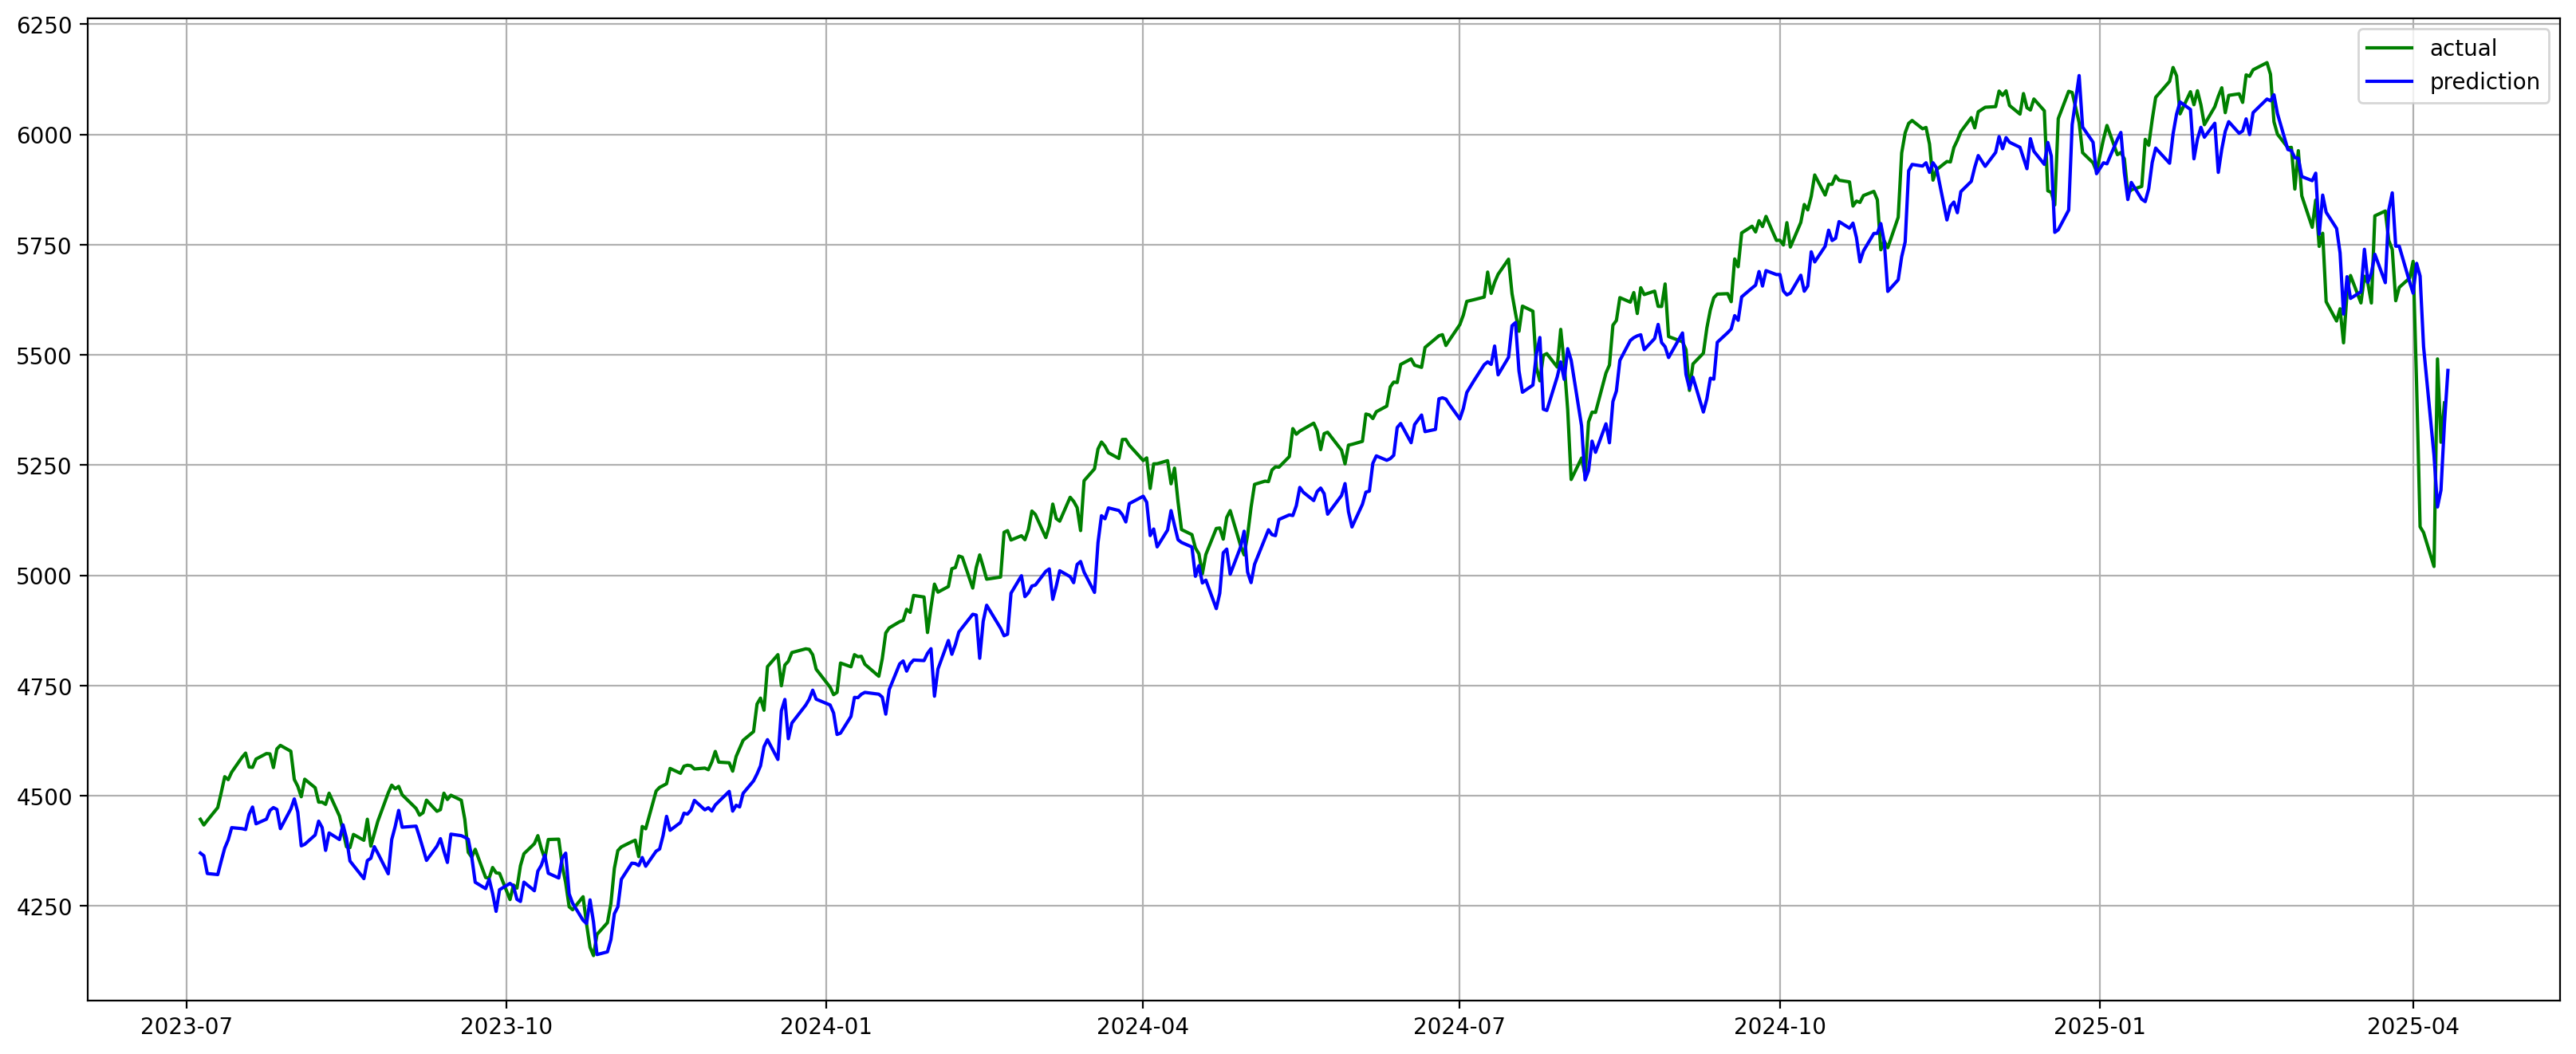

In [ ]:
plt.figure(figsize = (20,8))
plt.plot(result_df['target'][100:], label='actual', c="g")
plt.plot(result_df['prediction'][100:], label='prediction', c="b")
# plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-09-01'))
# plt.ylim(4300,5800)
plt.grid()
plt.legend()
plt.show()

In [ ]:
testing_df = result_df.copy()

test_data = get_new_values('ES=F', '2023-01-01')

test_data.columns = test_data.columns.get_level_values(0)

test_data = pd.DataFrame(test_data['Open'])

test_data.head()

test_data = testing_df.merge(test_data, left_index = True, right_index = True, how = 'left')

test_data = test_data.iloc[diff:]

[*********************100%***********************]  1 of 1 completed


In [ ]:
def add_signal(df):
    conditions = [
        df['prediction'] > df['prediction'].shift(1) * 1.002,
        df['prediction'] < df['prediction'].shift(1) * (1 - 0.002),
        (df['prediction'] >= df['prediction'].shift(1) * (1 - 0.002)) & (df['prediction'] <= df['prediction'].shift(1) * 1.002)
    ]

    choices = [int(1),int(-1),int(0)]

    df['signal'] = np.select(conditions, choices, default = np.nan)

    return df

In [ ]:
test_data = add_signal(test_data)

In [ ]:
test_data.tail(20)

,Close,High,Low,Volume,SMA_20,EMA_20,RSI,bb_mid_15,bb_high_15,bb_low_15,...,Volume_lag10,RSI_lag1,RSI_lag2,RSI_lag3,RSI_lag5,RSI_lag10,prediction,target,Open,signal
Date,,,,,,,,,,,,,,,,,,,,,
2025-03-17,5680.250000,5707.50,5599.00,2086734,5846.51250,5793.197395,39.814057,5763.616667,6063.490382,5463.742951,...,2610882.0,36.929204,27.915724,30.730306,29.843176,37.073906,5643.261333,5618.000000,5626.75,1.0
2025-03-18,5618.000000,5686.25,5600.00,1111733,5820.07500,5776.511929,37.009014,5740.150000,6025.549332,5454.750668,...,3353551.0,39.814057,36.929204,27.915724,28.306800,33.354719,5739.650268,5678.500000,5680.00,1.0
2025-03-19,5678.500000,5718.50,5606.25,704394,5795.85000,5767.177459,41.314416,5720.666667,5977.023050,5464.310283,...,2284032.0,37.009014,39.814057,36.929204,30.730306,39.033873,5664.686840,5662.500000,5618.50,-1.0
2025-03-20,5662.500000,5714.25,5631.50,412785,5772.15000,5757.208178,40.529480,5706.416667,5949.107730,5463.725603,...,2553819.0,41.314416,37.009014,39.814057,27.915724,33.788266,5685.808934,5617.799805,5680.00,1.0
2025-03-21,5617.799805,5674.25,5597.50,1629871,5751.58999,5743.931190,38.348586,5683.386654,5883.443930,5483.329378,...,2315005.0,40.529480,41.314416,37.009014,36.929204,36.383547,5728.367771,5815.500000,5664.00,1.0
2025-03-24,5815.500000,5825.50,5739.00,1404629,5742.32749,5750.747267,50.875006,5680.369987,5870.061371,5490.678603,...,2590102.0,38.348586,40.529480,41.314416,39.814057,29.843176,5663.963142,5826.500000,5740.00,-1.0
2025-03-25,5826.500000,5837.25,5802.25,1078548,5735.15249,5757.961813,51.462911,5682.836654,5879.445931,5486.227376,...,2623963.0,50.875006,38.348586,40.529480,37.009014,28.306800,5829.033717,5759.500000,5813.00,1.0
2025-03-26,5759.500000,5836.50,5743.00,1483959,5724.58999,5758.108307,47.734835,5676.719987,5855.801961,5497.638013,...,2004740.0,51.462911,50.875006,38.348586,41.314416,30.730306,5867.627948,5739.250000,5831.00,1.0
2025-03-27,5739.250000,5779.75,5720.00,1575855,5717.73999,5756.312278,46.640705,5676.253320,5854.593725,5497.912915,...,2163776.0,47.734835,51.462911,50.875006,40.529480,27.915724,5746.716438,5623.000000,5737.25,-1.0


In [ ]:
# If prediction for that day is 1, then calculate the difference between open and close for that day

test_data['correct up guess'] = np.where((test_data['signal'] == 1) & (test_data['Close'] > test_data['Open']), 1, 0)
test_data['correct down guess'] = np.where((test_data['signal'] == -1) & (test_data['Close'] < test_data['Open']), 1, 0)

test_data['incorrect up guess'] = np.where((test_data['signal'] == 1) & (test_data['Close'] < test_data['Open']), 1, 0)
test_data['incorrect down guess'] = np.where((test_data['signal'] == -1) & (test_data['Close'] > test_data['Open']), 1, 0)

test_data['correct no guess'] = np.where((test_data['signal'] == 0) & ((test_data['Close'] <= (test_data['Open'] * 1.002)) & (test_data['Close'] >= test_data['Open'] * (1 - 0.002))), 1, 0)
test_data['incorrect no guess'] = np.where((test_data['signal'] == 0) & ((test_data['Close'] >= (test_data['Open'] * 1.002)) & (test_data['Close'] <= test_data['Open'] * (1 - 0.002))), 1, 0)

test_data['profit'] = np.where(test_data['signal']==1, test_data['Close'] - test_data['Open'], 0)

In [ ]:
test_data.head(10)

,Close,High,Low,Volume,SMA_20,EMA_20,RSI,bb_mid_15,bb_high_15,bb_low_15,...,target,Open,signal,correct up guess,correct down guess,incorrect up guess,incorrect down guess,correct no guess,incorrect no guess,profit
Date,,,,,,,,,,,,,,,,,,,,,
2023-07-05,4483.75,4493.75,4466.25,1193759,4394.942505,4392.864479,69.342841,4425.940007,4507.053087,4344.826926,...,4447.00,4492.00,NaN,0,0,0,0,0,0,0.00
2023-07-06,4447.00,4483.50,4419.50,1741520,4402.805005,4398.020243,62.422380,4430.956673,4506.845923,4355.067424,...,4434.00,4481.75,0.0,0,0,0,0,0,0,0.00
2023-07-07,4434.00,4476.00,4431.50,1691644,4410.792505,4401.446886,60.147290,4434.940007,4504.041866,4365.838147,...,4444.25,4441.25,-1.0,0,1,0,0,0,0,0.00
2023-07-10,4444.25,4448.25,4411.25,1361155,4418.092505,4405.523373,61.337682,4436.123340,4505.213700,4367.032979,...,4473.50,4437.50,0.0,0,0,0,0,1,0,0.00
2023-07-11,4473.50,4478.50,4439.00,1340232,4426.530005,4411.997338,64.573100,4437.466667,4508.741504,4366.191830,...,4507.50,4445.75,1.0,1,0,0,0,0,0,27.75
2023-07-12,4507.50,4523.75,4470.00,1784296,4434.767505,4421.092830,67.916865,4442.316667,4522.182283,4362.451050,...,4543.50,4471.00,1.0,1,0,0,0,0,0,36.50
2023-07-13,4543.50,4551.50,4509.25,1158193,4443.355005,4432.750655,71.019916,4451.266667,4544.261188,4358.272146,...,4536.75,4510.50,1.0,1,0,0,0,0,0,33.00
2023-07-14,4536.75,4560.50,4531.00,1381069,4451.480005,4442.655355,69.666288,4458.800000,4560.171876,4357.428124,...,4553.75,4539.50,1.0,0,0,1,0,0,0,-2.75
2023-07-17,4553.75,4565.75,4528.00,1057965,4457.842505,4453.235797,71.150077,4469.783333,4574.392618,4365.174049,...,4587.75,4536.00,0.0,0,0,0,0,0,0,0.00


In [ ]:
test_data = test_data.drop(axis = 1, columns = ['SMA30', 'SMA50', 'SMA70', 'EMA30', 'EMA50', 'EMA70', 'rsi', 'bb_high', 'bb_low',])

KeyError: "['SMA30', 'SMA50', 'SMA70', 'EMA30', 'EMA50', 'EMA70', 'rsi', 'bb_high', 'bb_low'] not found in axis"

In [ ]:
correct_up_guesses = test_data['correct up guess'].sum()

correct_down_guesses = test_data['correct down guess'].sum()

incorrect_up_guesses = test_data['incorrect up guess'].sum()

incorrect_down_guesses = test_data['incorrect down guess'].sum()

correct_no_guesses = test_data['correct no guess'].sum()
incorrect_no_guesses = test_data['incorrect no guess'].sum()

print(f"""
    Number of correct up guesses: {correct_up_guesses}
    Number of incorrect up guesses: {incorrect_up_guesses}
    Number of correct down guesses: {correct_down_guesses}
    Number of incorrect down guesses: {incorrect_down_guesses}
    Number of correct no guesses: {correct_no_guesses}
    Number of incorrect no guesses: {incorrect_no_guesses}
""")


    Number of correct up guesses: 117
    Number of incorrect up guesses: 90
    Number of correct down guesses: 71
    Number of incorrect down guesses: 78
    Number of correct no guesses: 24
    Number of incorrect no guesses: 0



In [ ]:
print(test_data['profit'].sum())

21.48046875
